In [1]:
from pathlib import Path
import pandas as pd
import requests

base_url = "https://raw.githubusercontent.com/genesys-neu/TRACTOR/main/logs/SingleUE/Trial1"

files = {
    "embb_clean.csv": "embb",
    "mmtc_clean.csv": "mmtc",
    "urllc_clean.csv": "urllc"
}

data_dir = Path("tractor_trial1")
data_dir.mkdir(exist_ok=True)

dfs = []

for filename, label in files.items():
    url = f"{base_url}/{filename}"
    local_path = data_dir / filename

    response = requests.get(url)
    response.raise_for_status()

    local_path.write_bytes(response.content)

    df = pd.read_csv(local_path)
    df["slice_label"] = label
    dfs.append(df)

combined_df = pd.concat(dfs, ignore_index=True)

output_path = data_dir / "singleue_trial1_combined.csv"
combined_df.to_csv(output_path, index=False)

print(combined_df.shape)
print(combined_df["slice_label"].value_counts())
print(f"Saved to: {output_path}")

(20387, 20)
slice_label
mmtc     14631
embb      4409
urllc     1347
Name: count, dtype: int64
Saved to: tractor_trial1\singleue_trial1_combined.csv


In [22]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

In [23]:
df = pd.read_csv("singleue_trial1_combined.csv")

df.head()

,Timestamp,dl_mcs,dl_n_samples,dl_buffer [bytes],tx_brate downlink [Mbps],tx_pkts downlink,tx_errors downlink (%),dl_cqi,ul_mcs,ul_n_samples,ul_buffer [bytes],rx_brate uplink [Mbps],rx_pkts uplink,rx_errors uplink (%),ul_sinr,phr,sum_requested_prbs,sum_granted_prbs,ul_turbo_iters,slice_label
0,1.670000e+12,2.25,24,0,0.004736,7,0,6.33333,11.6897,29,0,0.1,8,0.0,35.8689,31,2,24,1.0,embb
1,1.670000e+12,2.60,15,0,0.004896,4,0,6.85714,11.3810,21,0,0.1,6,0.0,36.3460,31,0,15,1.0,embb
2,1.670000e+12,9.00,4,0,0.001824,1,0,6.83333,11.0000,7,0,0.1,2,0.0,36.7170,31,0,3,1.0,embb
3,1.670000e+12,0.00,0,0,0.000000,0,0,6.50000,0.0000,0,0,0.0,0,0.0,0.0000,0,0,0,0.0,embb
4,1.670000e+12,0.00,0,0,0.000000,0,0,6.66667,0.0000,0,0,0.0,0,0.0,0.0000,0,0,0,0.0,embb


In [24]:
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_", regex=False)
    .str.replace("[", "", regex=False)
    .str.replace("]", "", regex=False)
    .str.replace("(", "", regex=False)
    .str.replace(")", "", regex=False)
    .str.replace("%", "pct", regex=False)
)

df.head()

,timestamp,dl_mcs,dl_n_samples,dl_buffer_bytes,tx_brate_downlink_mbps,tx_pkts_downlink,tx_errors_downlink_pct,dl_cqi,ul_mcs,ul_n_samples,ul_buffer_bytes,rx_brate_uplink_mbps,rx_pkts_uplink,rx_errors_uplink_pct,ul_sinr,phr,sum_requested_prbs,sum_granted_prbs,ul_turbo_iters,slice_label
0,1.670000e+12,2.25,24,0,0.004736,7,0,6.33333,11.6897,29,0,0.1,8,0.0,35.8689,31,2,24,1.0,embb
1,1.670000e+12,2.60,15,0,0.004896,4,0,6.85714,11.3810,21,0,0.1,6,0.0,36.3460,31,0,15,1.0,embb
2,1.670000e+12,9.00,4,0,0.001824,1,0,6.83333,11.0000,7,0,0.1,2,0.0,36.7170,31,0,3,1.0,embb
3,1.670000e+12,0.00,0,0,0.000000,0,0,6.50000,0.0000,0,0,0.0,0,0.0,0.0000,0,0,0,0.0,embb
4,1.670000e+12,0.00,0,0,0.000000,0,0,6.66667,0.0000,0,0,0.0,0,0.0,0.0000,0,0,0,0.0,embb


In [25]:
df.columns

Index(['timestamp', 'dl_mcs', 'dl_n_samples', 'dl_buffer_bytes',
       'tx_brate_downlink_mbps', 'tx_pkts_downlink', 'tx_errors_downlink_pct',
       'dl_cqi', 'ul_mcs', 'ul_n_samples', 'ul_buffer_bytes',
       'rx_brate_uplink_mbps', 'rx_pkts_uplink', 'rx_errors_uplink_pct',
       'ul_sinr', 'phr', 'sum_requested_prbs', 'sum_granted_prbs',
       'ul_turbo_iters', 'slice_label'],
      dtype='object')

In [26]:
df.shape

(20387, 20)

In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20387 entries, 0 to 20386
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   timestamp               20387 non-null  float64
 1   dl_mcs                  20387 non-null  float64
 2   dl_n_samples            20387 non-null  int64  
 3   dl_buffer_bytes         20387 non-null  int64  
 4   tx_brate_downlink_mbps  20387 non-null  float64
 5   tx_pkts_downlink        20387 non-null  int64  
 6   tx_errors_downlink_pct  20387 non-null  int64  
 7   dl_cqi                  20387 non-null  float64
 8   ul_mcs                  20387 non-null  float64
 9   ul_n_samples            20387 non-null  int64  
 10  ul_buffer_bytes         20387 non-null  int64  
 11  rx_brate_uplink_mbps    20387 non-null  float64
 12  rx_pkts_uplink          20387 non-null  int64  
 13  rx_errors_uplink_pct    20387 non-null  float64
 14  ul_sinr                 20387 non-null

In [28]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
timestamp,20387.0,1.667969e+12,1.274193e+09,1.667160e+12,1.667170e+12,1.667170e+12,1.670000e+12,1.670000e+12
dl_mcs,20387.0,2.876476e+00,5.405950e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.863640e+01
dl_n_samples,20387.0,5.691220e+01,1.686278e+02,0.000000e+00,0.000000e+00,0.000000e+00,3.000000e+00,8.790000e+02
dl_buffer_bytes,20387.0,2.470714e+03,1.771572e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.921530e+05
tx_brate_downlink_mbps,20387.0,2.665407e-01,8.018747e-01,0.000000e+00,0.000000e+00,0.000000e+00,1.568000e-03,5.901500e+00
tx_pkts_downlink,20387.0,1.625384e+01,4.818949e+01,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,2.510000e+02
tx_errors_downlink_pct,20387.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
dl_cqi,20387.0,8.100428e+00,8.441309e-01,1.000000e-01,8.166670e+00,8.333330e+00,8.571430e+00,9.833330e+00
ul_mcs,20387.0,3.745694e+00,6.356081e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.164145e+01,1.600000e+01
ul_n_samples,20387.0,2.600128e+01,7.746801e+01,0.000000e+00,0.000000e+00,0.000000e+00,7.000000e+00,8.750000e+02


In [29]:
missing = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_percent": df.isna().mean() * 100
})

missing.sort_values("missing_count", ascending=False)

,missing_count,missing_percent
timestamp,0,0.0
dl_mcs,0,0.0
dl_n_samples,0,0.0
dl_buffer_bytes,0,0.0
tx_brate_downlink_mbps,0,0.0
tx_pkts_downlink,0,0.0
tx_errors_downlink_pct,0,0.0
dl_cqi,0,0.0
ul_mcs,0,0.0
ul_n_samples,0,0.0


In [30]:
df.duplicated().sum()

np.int64(14309)

In [31]:
df = df.drop_duplicates()

In [32]:
target = "slice_label"

df[target].value_counts()

slice_label
embb     2418
mmtc     2338
urllc    1322
Name: count, dtype: int64

In [33]:
df[target].value_counts(normalize=True) * 100

slice_label
embb     39.782823
mmtc     38.466601
urllc    21.750576
Name: proportion, dtype: float64

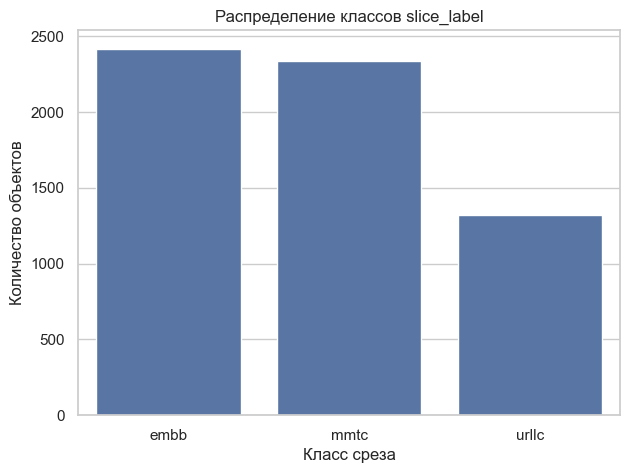

In [34]:
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x=target, order=df[target].value_counts().index)
plt.title("Распределение классов slice_label")
plt.xlabel("Класс среза")
plt.ylabel("Количество объектов")
plt.show()

In [35]:
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()

numeric_cols

['timestamp',
 'dl_mcs',
 'dl_n_samples',
 'dl_buffer_bytes',
 'tx_brate_downlink_mbps',
 'tx_pkts_downlink',
 'tx_errors_downlink_pct',
 'dl_cqi',
 'ul_mcs',
 'ul_n_samples',
 'ul_buffer_bytes',
 'rx_brate_uplink_mbps',
 'rx_pkts_uplink',
 'rx_errors_uplink_pct',
 'ul_sinr',
 'phr',
 'sum_requested_prbs',
 'sum_granted_prbs',
 'ul_turbo_iters']

In [36]:
len(numeric_cols)

19

In [37]:
unique_info = pd.DataFrame({
    "column": df.columns,
    "n_unique": df.nunique().values,
    "dtype": df.dtypes.astype(str).values
})

unique_info.sort_values("n_unique")

,column,n_unique,dtype
6,tx_errors_downlink_pct,1,int64
15,phr,2,int64
13,rx_errors_uplink_pct,2,float64
0,timestamp,3,float64
18,ul_turbo_iters,3,float64
19,slice_label,3,object
7,dl_cqi,37,float64
12,rx_pkts_uplink,157,int64
10,ul_buffer_bytes,227,int64
5,tx_pkts_downlink,237,int64


In [57]:
low_unique_cols = df.columns[df.nunique() <= 3].tolist()

low_unique_cols

['timestamp',
 'tx_errors_downlink_pct',
 'rx_errors_uplink_pct',
 'phr',
 'ul_turbo_iters',
 'slice_label']

In [59]:
target = "slice_label"

low_unique_cols = [
    col for col in df.columns
    if col != target and df[col].nunique() <= 3
]

low_unique_info = pd.DataFrame({
    "column": low_unique_cols,
    "n_unique": [df[col].nunique() for col in low_unique_cols]
})

display(low_unique_info)

df = df.drop(columns=low_unique_cols)

df.shape

,column,n_unique
0,timestamp,3
1,tx_errors_downlink_pct,1
2,rx_errors_uplink_pct,2
3,phr,2
4,ul_turbo_iters,3


(6078, 15)

In [63]:
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()

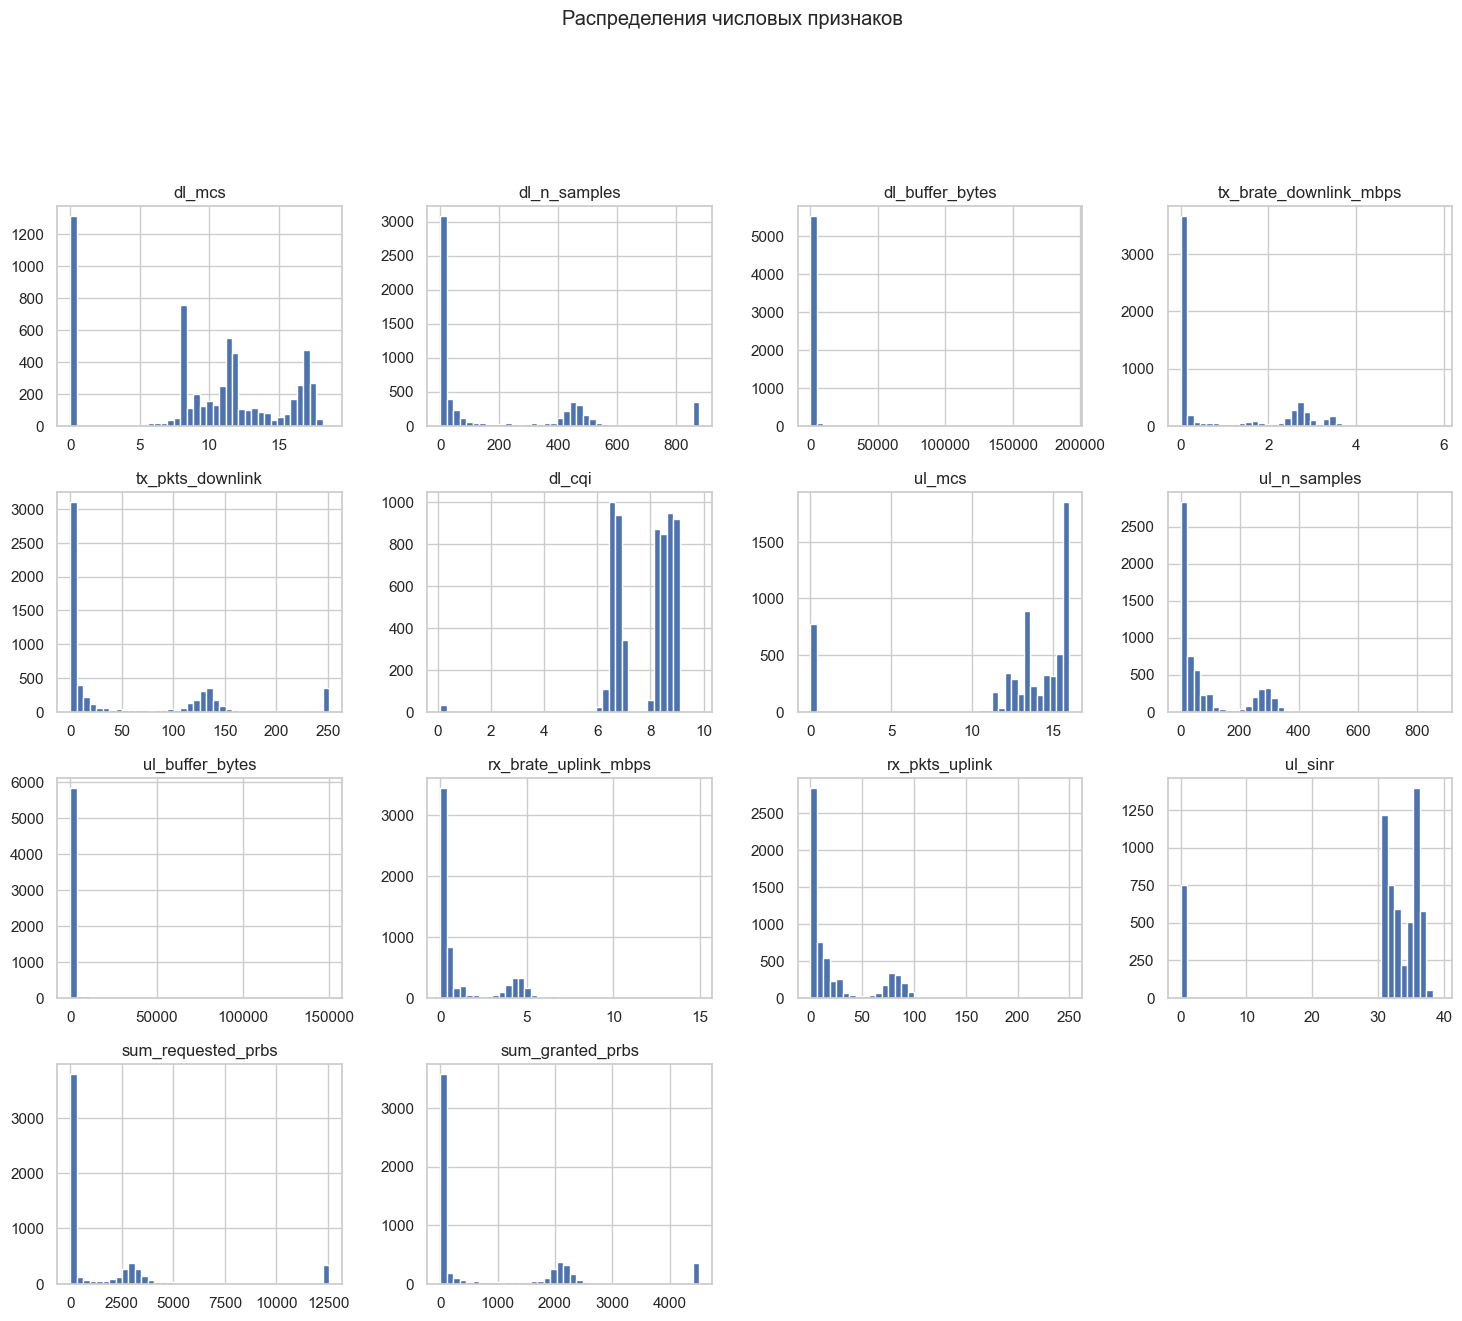

In [64]:
df[numeric_cols].hist(figsize=(18, 14), bins=40)
plt.suptitle("Распределения числовых признаков", y=1.02)
plt.show()

In [65]:
important_features = [
    "dl_mcs",
    "dl_n_samples",
    "dl_buffer_bytes",
    "tx_brate_downlink_mbps",
    "tx_pkts_downlink",
    "dl_cqi",
    "ul_mcs",
    "ul_n_samples",
    "rx_brate_uplink_mbps",
    "rx_pkts_uplink",
    "ul_sinr",
    "phr",
    "sum_requested_prbs",
    "sum_granted_prbs",
    "ul_turbo_iters"
]

important_features = [col for col in important_features if col in df.columns]

important_features

['dl_mcs',
 'dl_n_samples',
 'dl_buffer_bytes',
 'tx_brate_downlink_mbps',
 'tx_pkts_downlink',
 'dl_cqi',
 'ul_mcs',
 'ul_n_samples',
 'rx_brate_uplink_mbps',
 'rx_pkts_uplink',
 'ul_sinr',
 'sum_requested_prbs',
 'sum_granted_prbs']

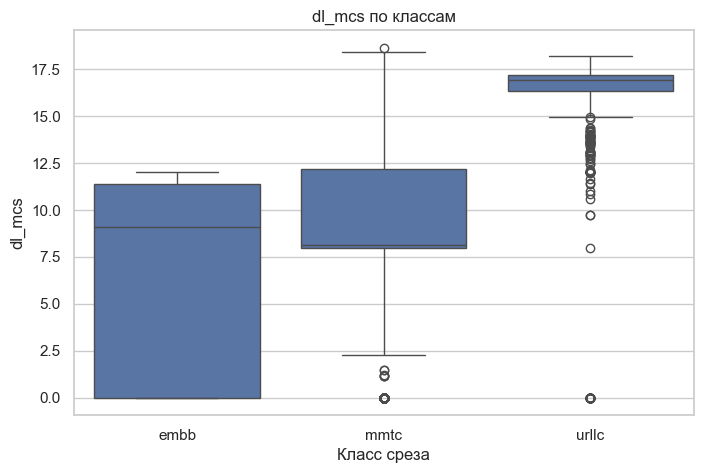

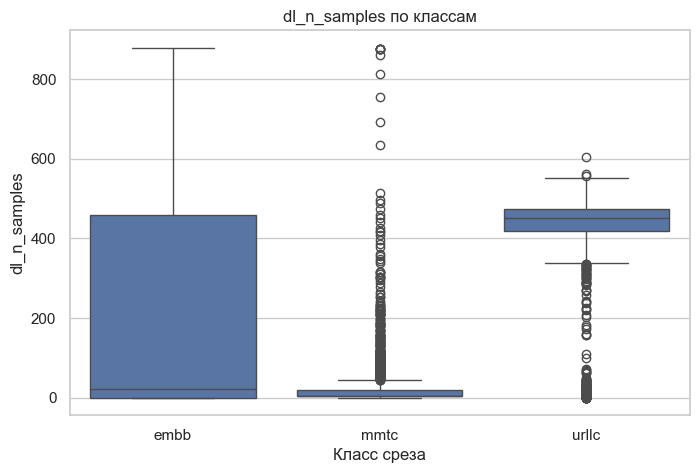

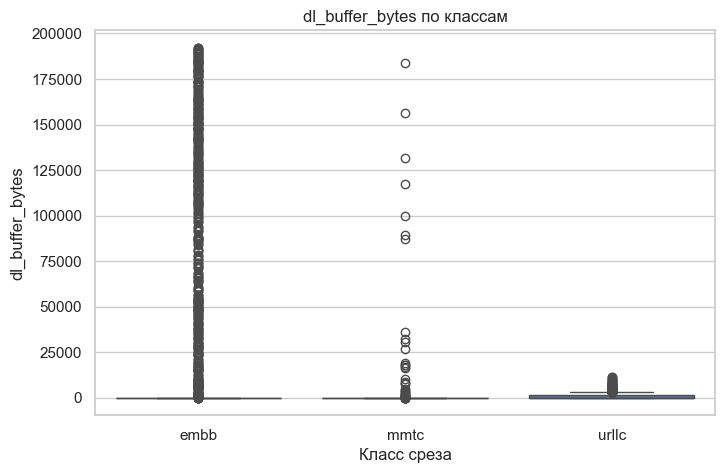

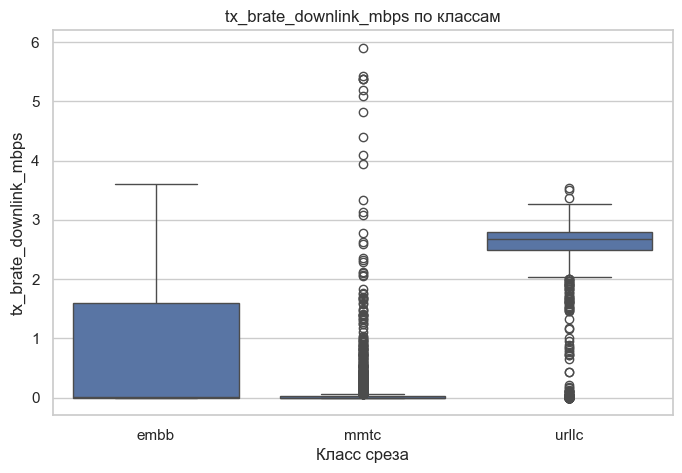

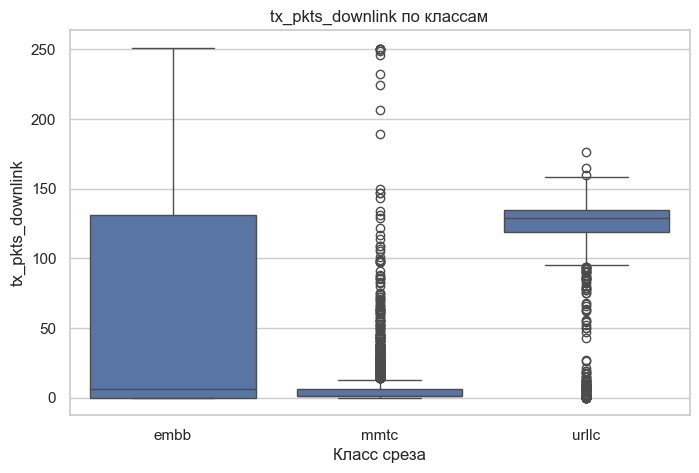

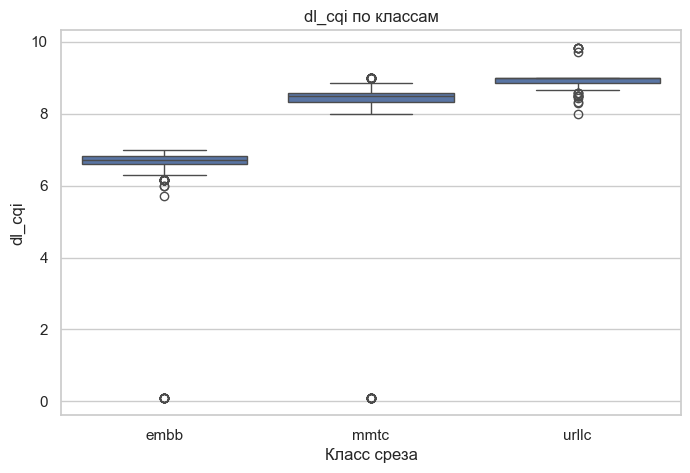

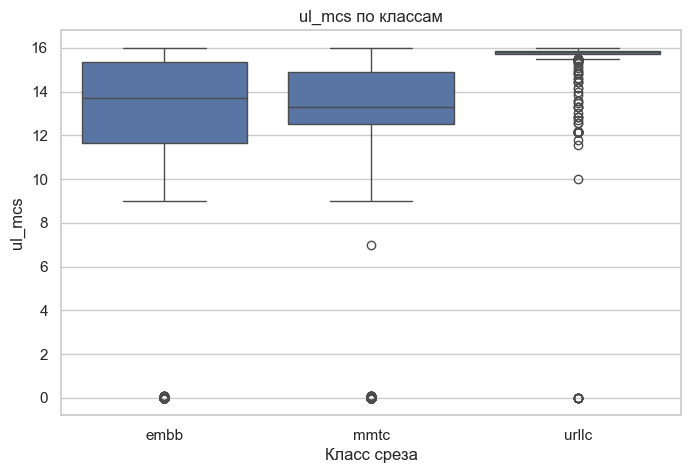

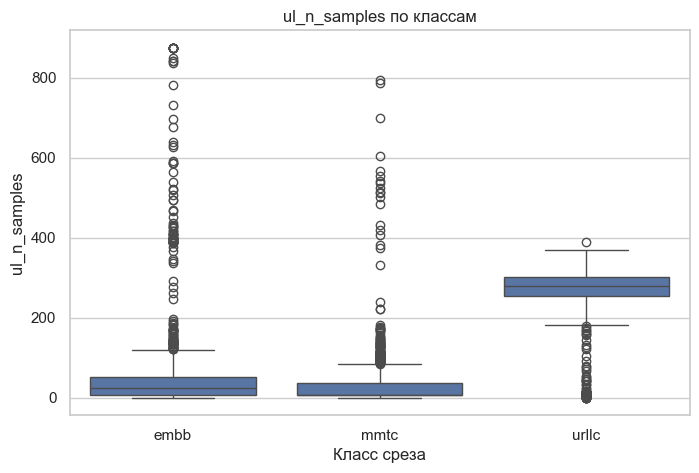

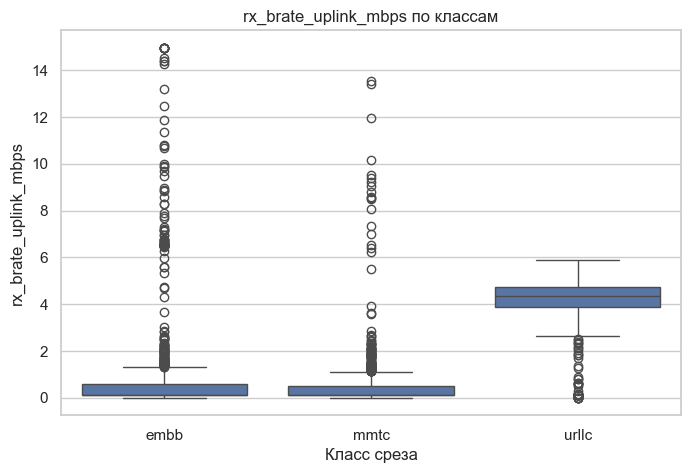

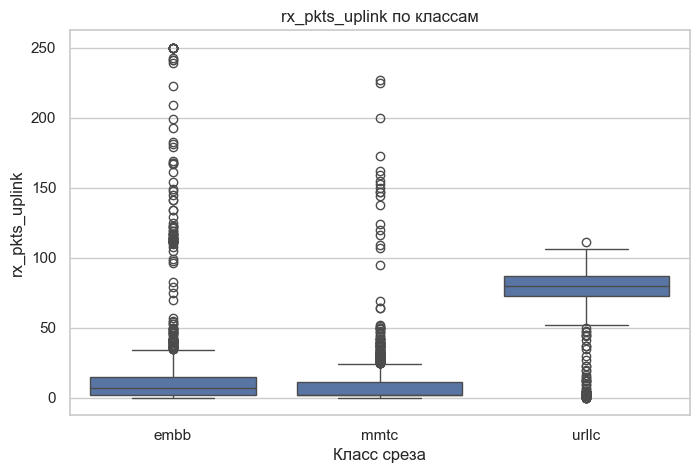

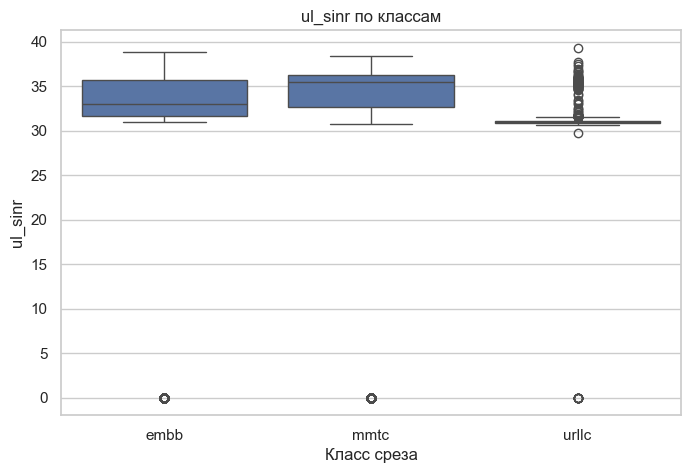

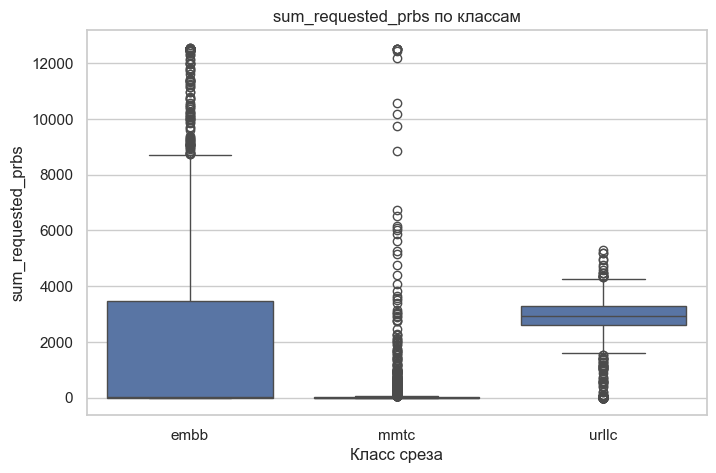

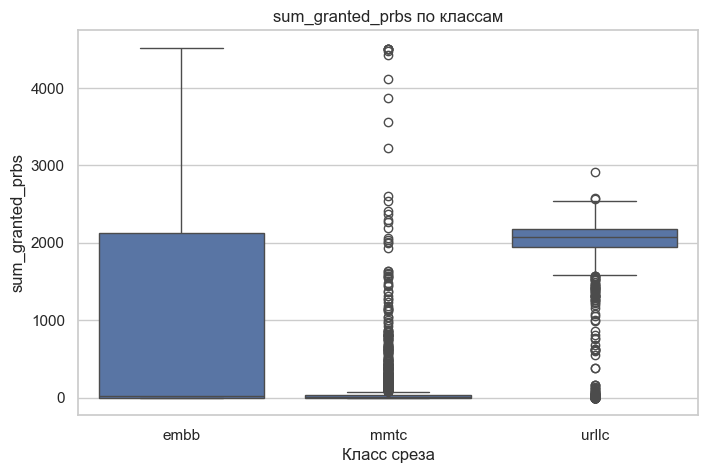

In [66]:
for col in important_features:
    plt.figure(figsize=(8, 5))
    sns.boxplot(data=df, x=target, y=col)
    plt.title(f"{col} по классам")
    plt.xlabel("Класс среза")
    plt.ylabel(col)
    plt.show()

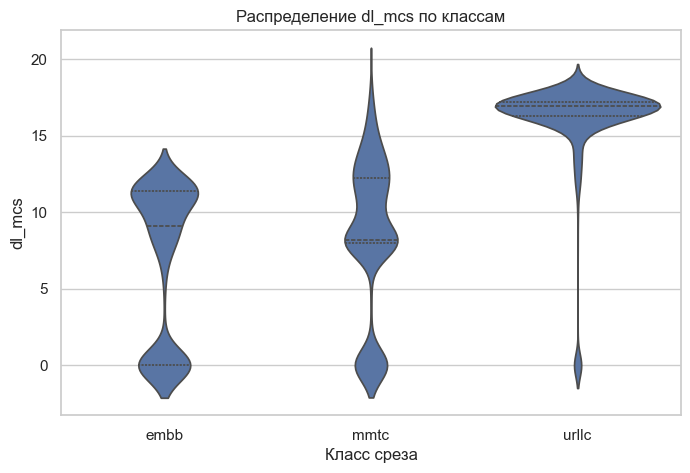

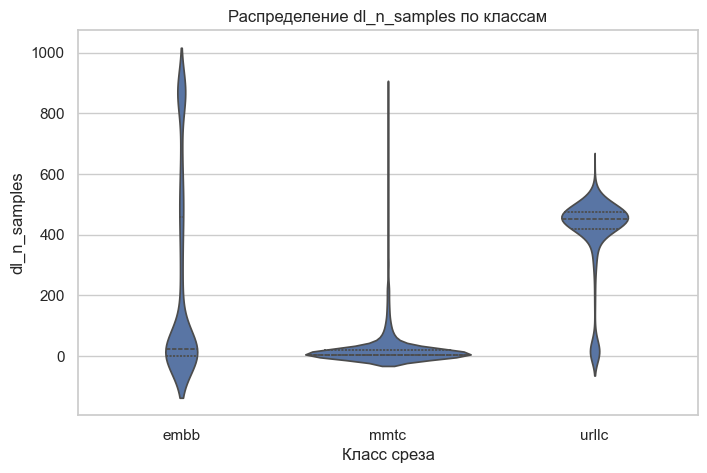

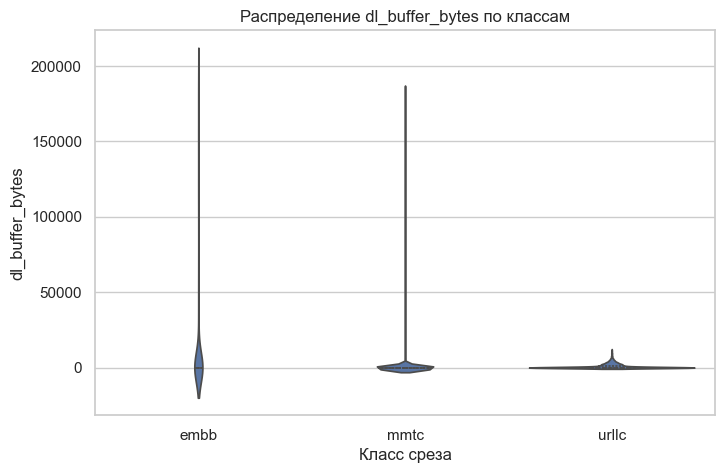

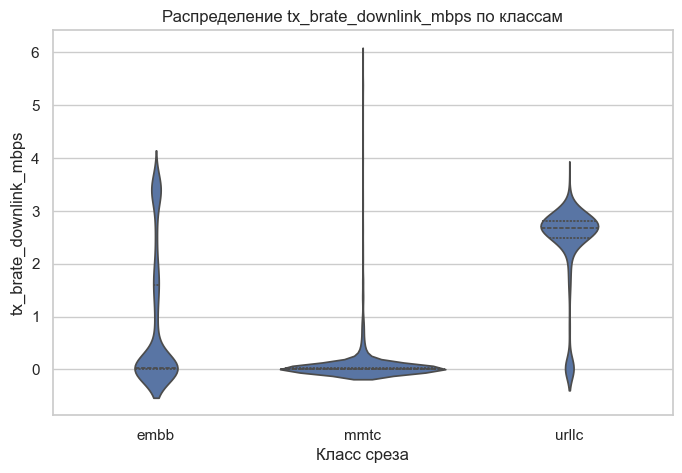

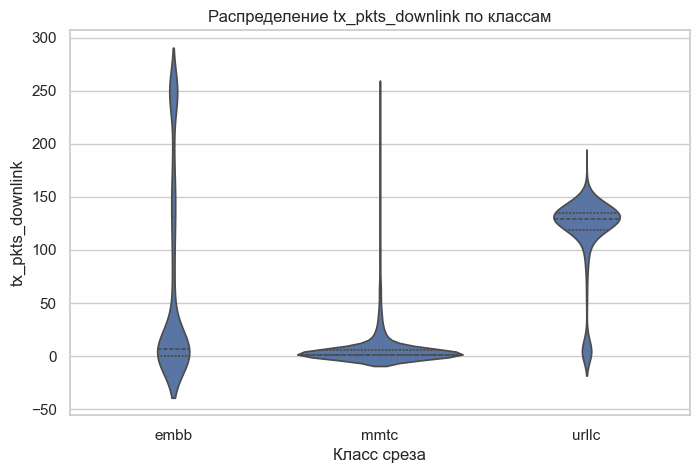

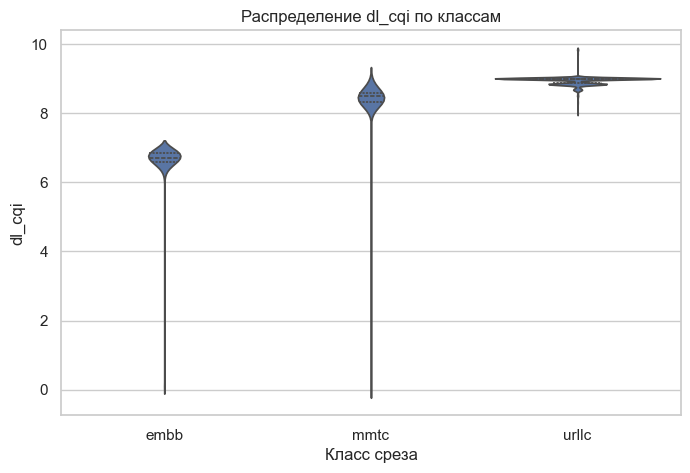

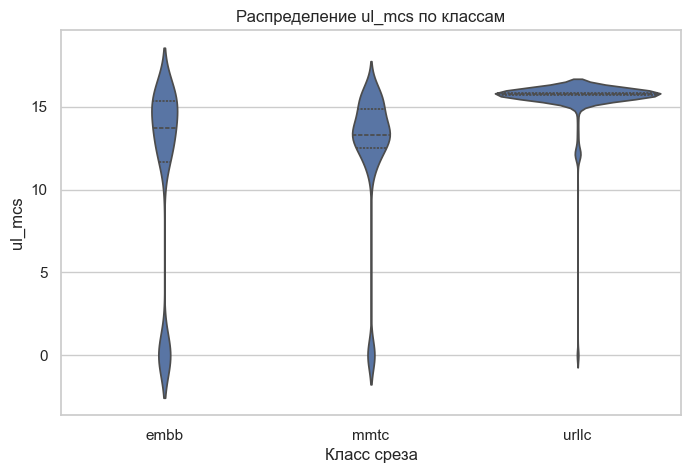

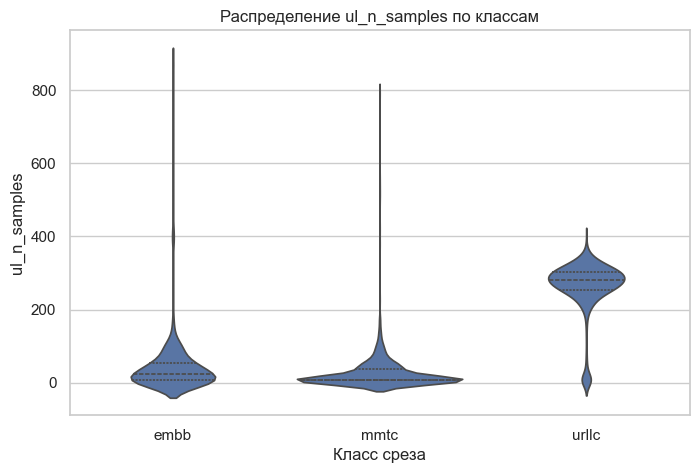

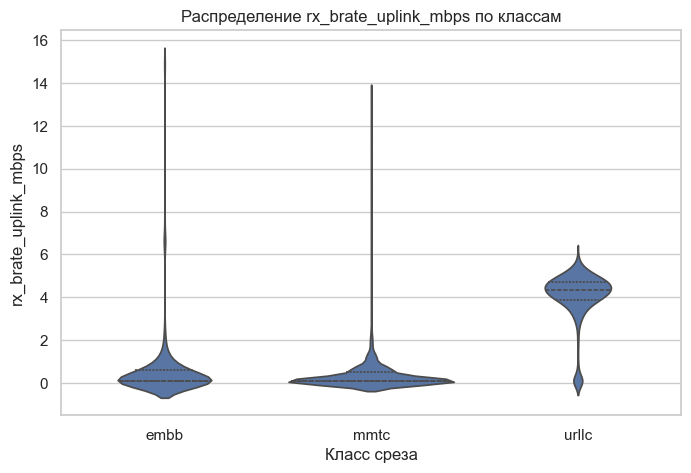

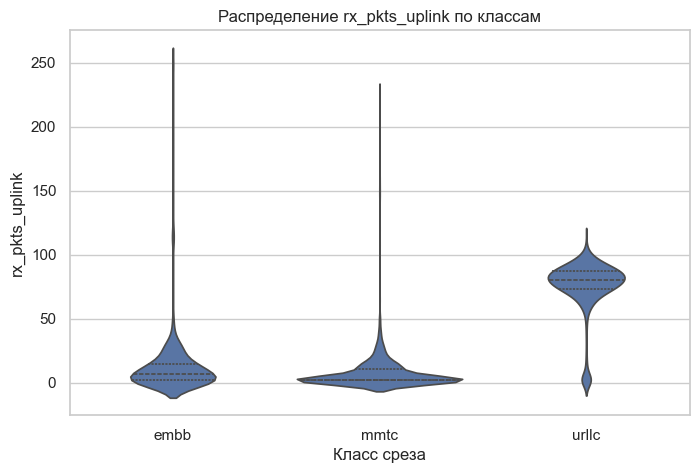

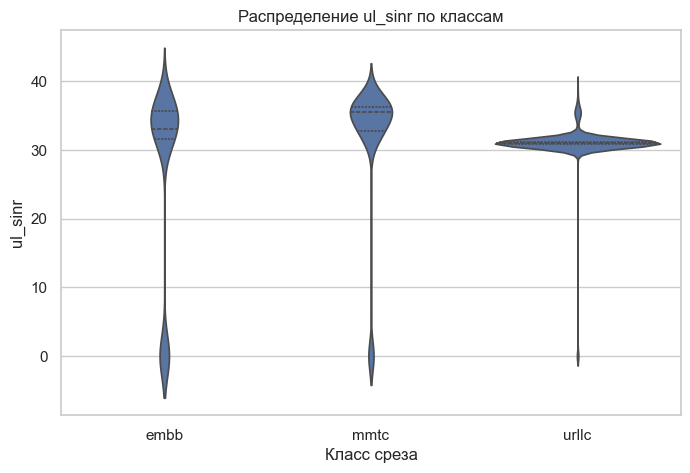

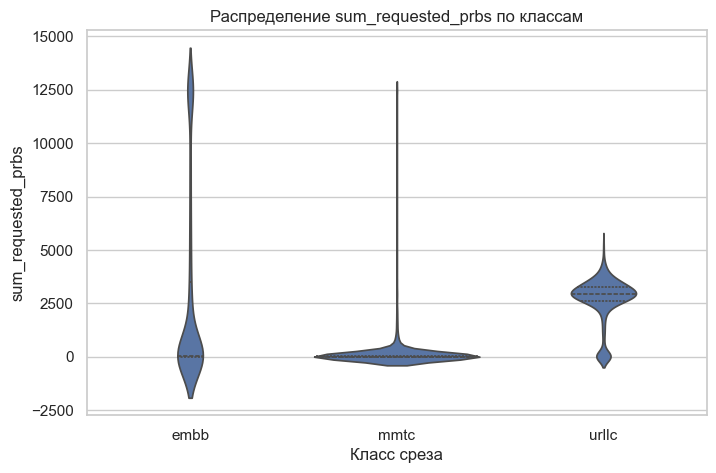

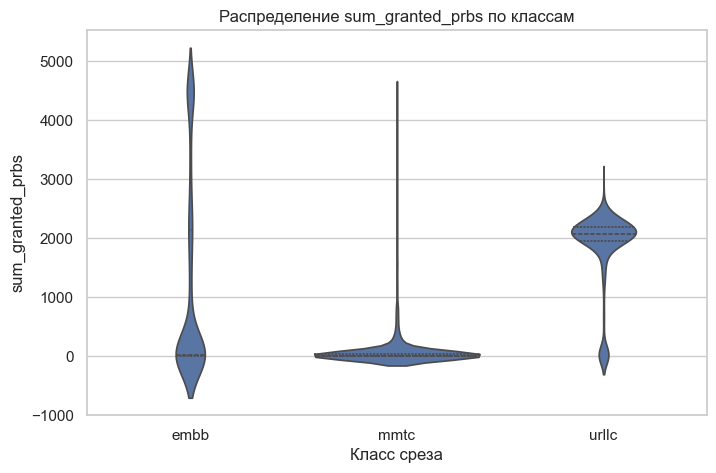

In [67]:
for col in important_features:
    plt.figure(figsize=(8, 5))
    sns.violinplot(data=df, x=target, y=col, inner="quartile")
    plt.title(f"Распределение {col} по классам")
    plt.xlabel("Класс среза")
    plt.ylabel(col)
    plt.show()

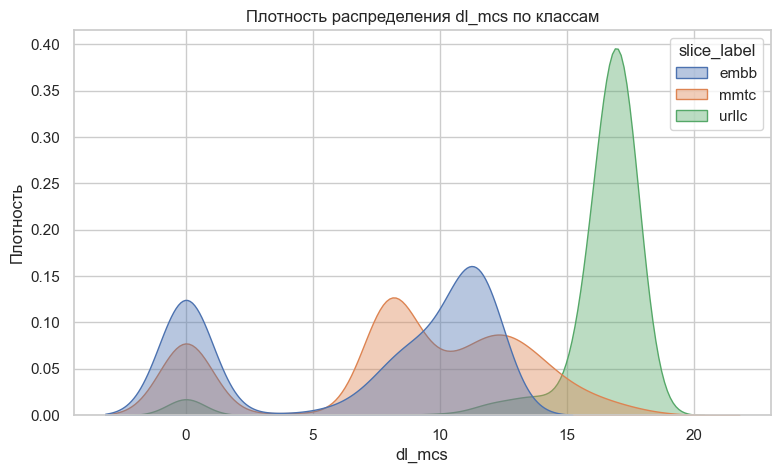

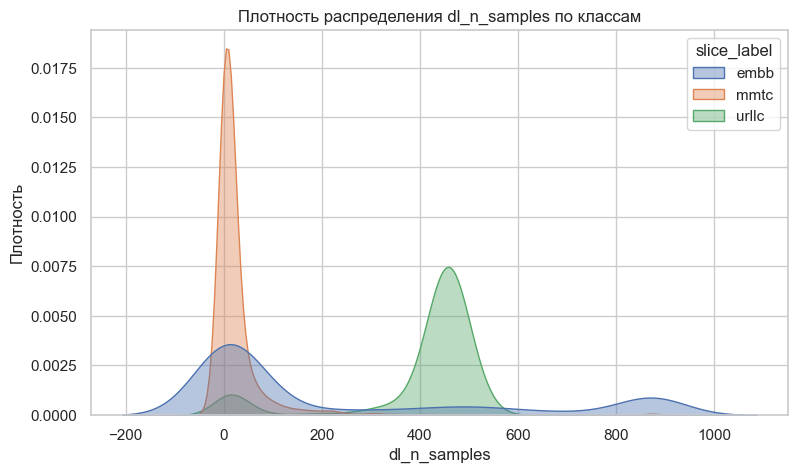

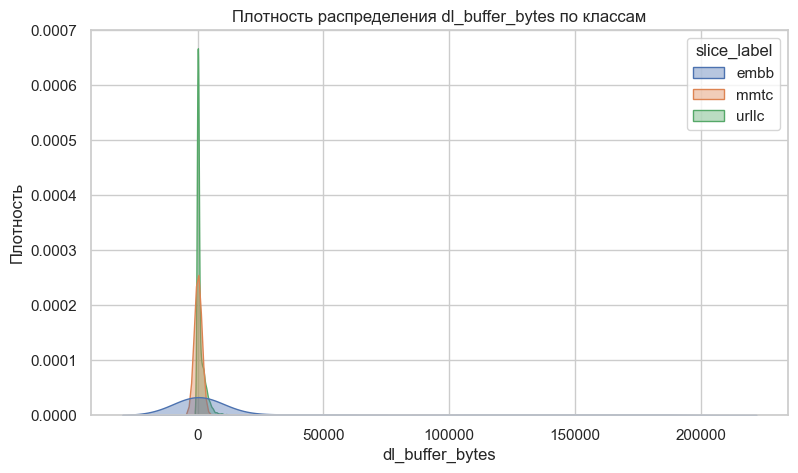

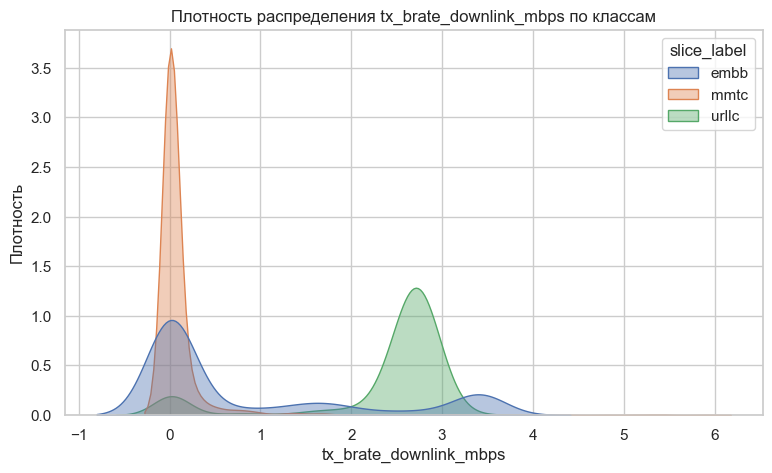

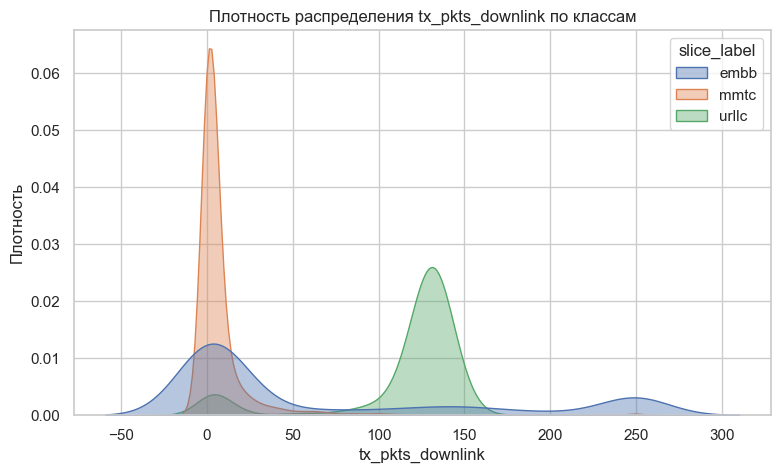

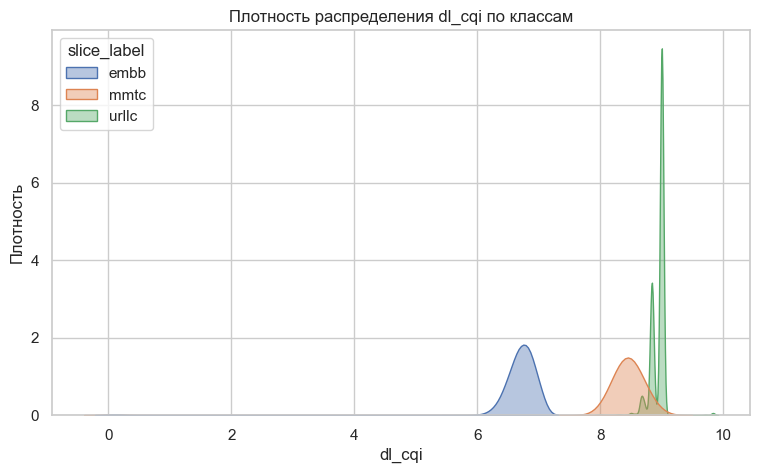

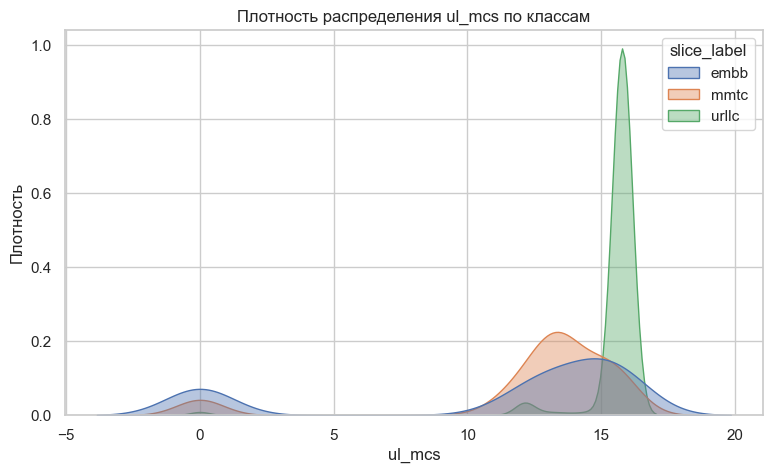

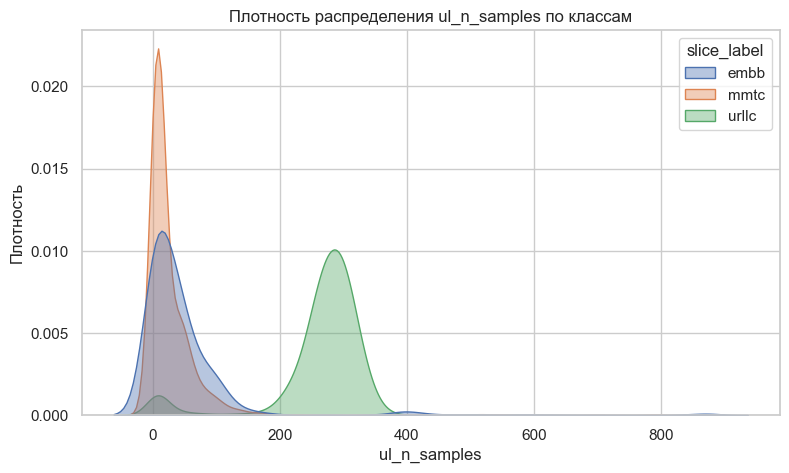

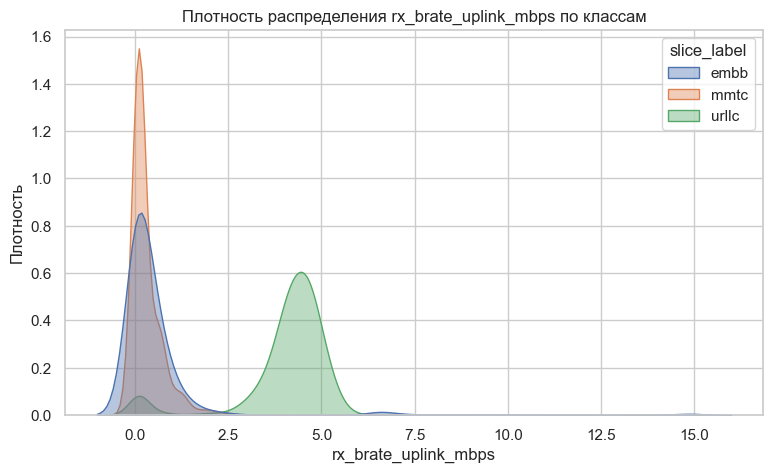

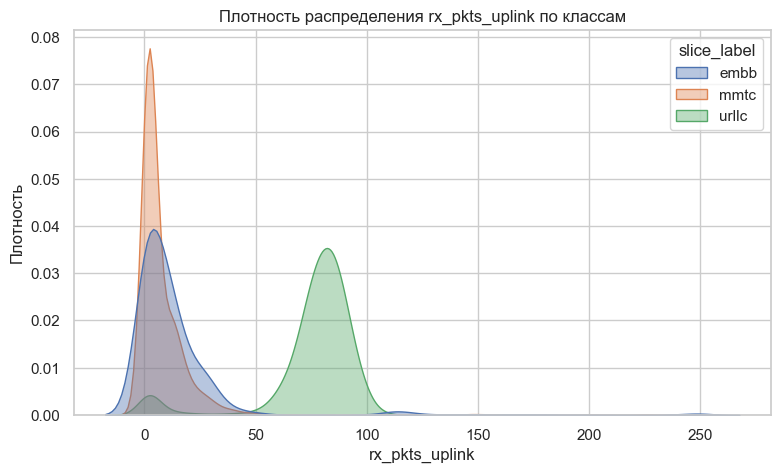

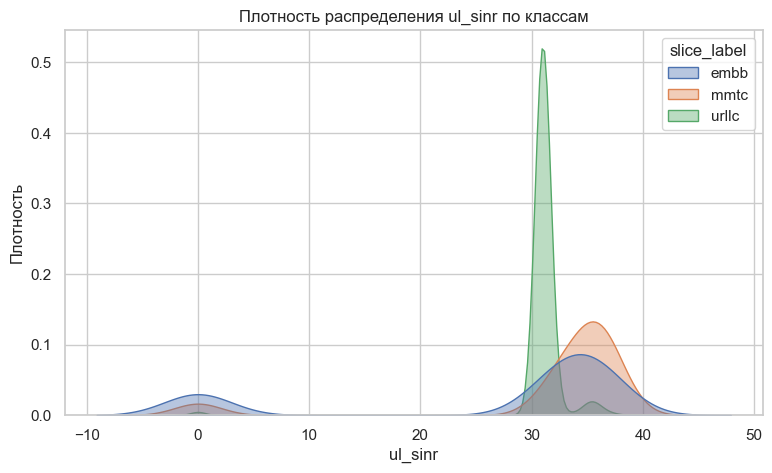

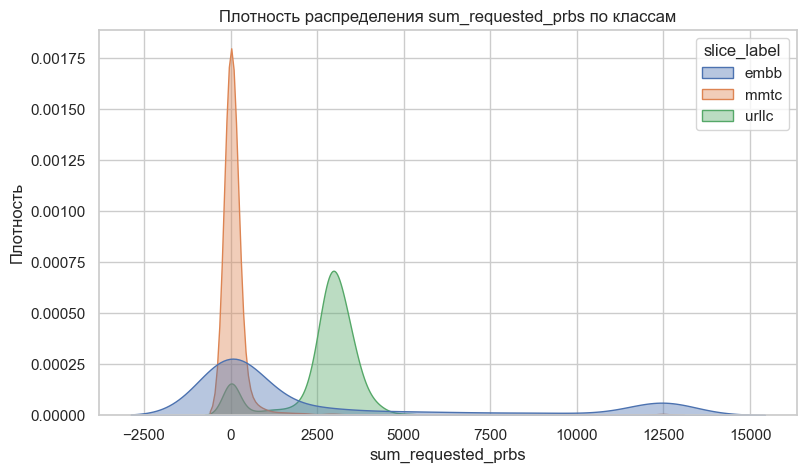

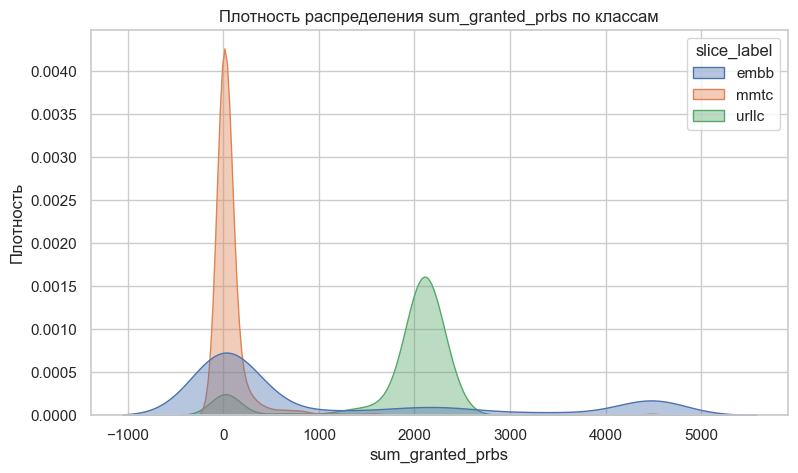

In [68]:
for col in important_features:
    plt.figure(figsize=(9, 5))
    sns.kdeplot(data=df, x=col, hue=target, fill=True, common_norm=False, alpha=0.4)
    plt.title(f"Плотность распределения {col} по классам")
    plt.xlabel(col)
    plt.ylabel("Плотность")
    plt.show()

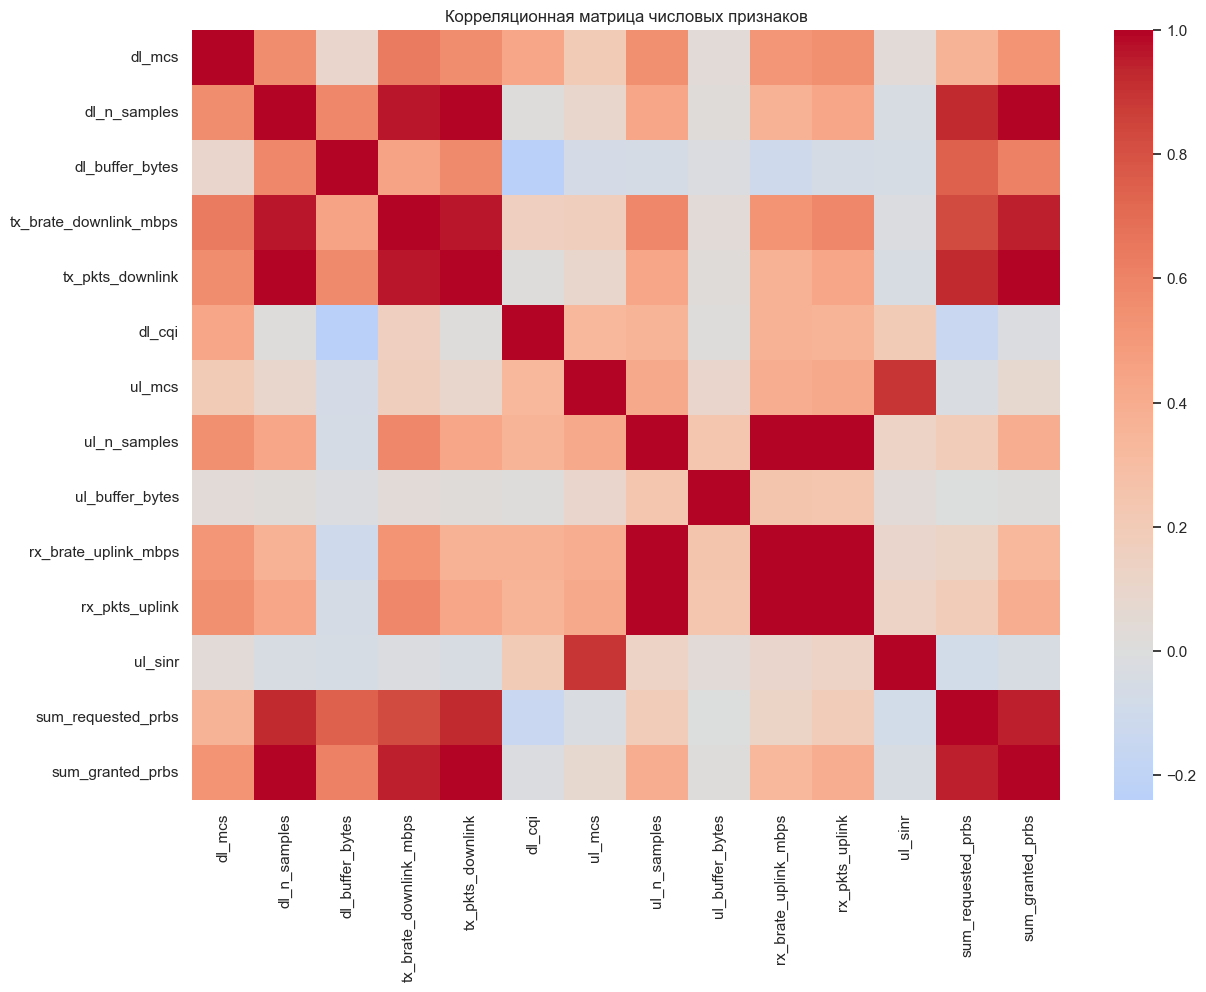

In [69]:
corr = df[numeric_cols].corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr, cmap="coolwarm", center=0, annot=False)
plt.title("Корреляционная матрица числовых признаков")
plt.show()

In [70]:
corr_pairs = (
    corr.abs()
    .where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    .stack()
    .sort_values(ascending=False)
)

corr_pairs.head(20)

ul_n_samples            rx_pkts_uplink            0.999968
dl_n_samples            tx_pkts_downlink          0.999360
                        sum_granted_prbs          0.996242
tx_pkts_downlink        sum_granted_prbs          0.995630
rx_brate_uplink_mbps    rx_pkts_uplink            0.991535
ul_n_samples            rx_brate_uplink_mbps      0.991522
tx_brate_downlink_mbps  tx_pkts_downlink          0.960332
dl_n_samples            tx_brate_downlink_mbps    0.959627
tx_brate_downlink_mbps  sum_granted_prbs          0.950289
sum_requested_prbs      sum_granted_prbs          0.948697
dl_n_samples            sum_requested_prbs        0.924593
tx_pkts_downlink        sum_requested_prbs        0.924032
ul_mcs                  ul_sinr                   0.891149
tx_brate_downlink_mbps  sum_requested_prbs        0.825125
dl_buffer_bytes         sum_requested_prbs        0.739380
dl_mcs                  tx_brate_downlink_mbps    0.633805
dl_buffer_bytes         sum_granted_prbs          0.6149

In [71]:
class_means = df.groupby(target)[numeric_cols].mean()

class_means

,dl_mcs,dl_n_samples,dl_buffer_bytes,tx_brate_downlink_mbps,tx_pkts_downlink,dl_cqi,ul_mcs,ul_n_samples,ul_buffer_bytes,rx_brate_uplink_mbps,rx_pkts_uplink,ul_sinr,sum_requested_prbs,sum_granted_prbs
slice_label,,,,,,,,,,,,,,
embb,6.915781,229.786600,19860.035567,0.838131,65.646402,6.687983,10.994067,48.392473,3197.447477,0.575372,13.805211,26.572817,2751.106286,1108.205955
mmtc,8.503497,28.412746,489.814799,0.105140,8.086399,8.390275,12.513860,27.680068,1804.505560,0.360263,7.987169,32.031773,175.143713,96.728828
urllc,16.071395,406.631619,910.506808,2.391215,116.152042,8.941268,15.503662,263.291982,5798.019667,4.059652,75.568079,30.995327,2704.715582,1866.054463


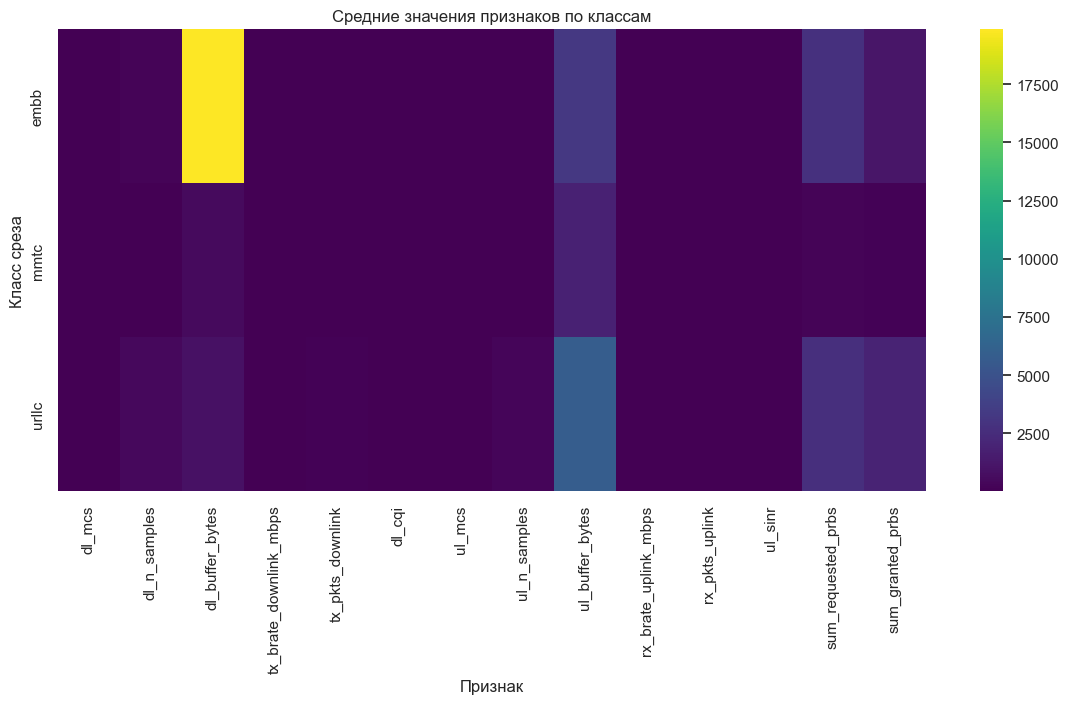

In [72]:
plt.figure(figsize=(14, 6))
sns.heatmap(class_means, cmap="viridis")
plt.title("Средние значения признаков по классам")
plt.xlabel("Признак")
plt.ylabel("Класс среза")
plt.show()

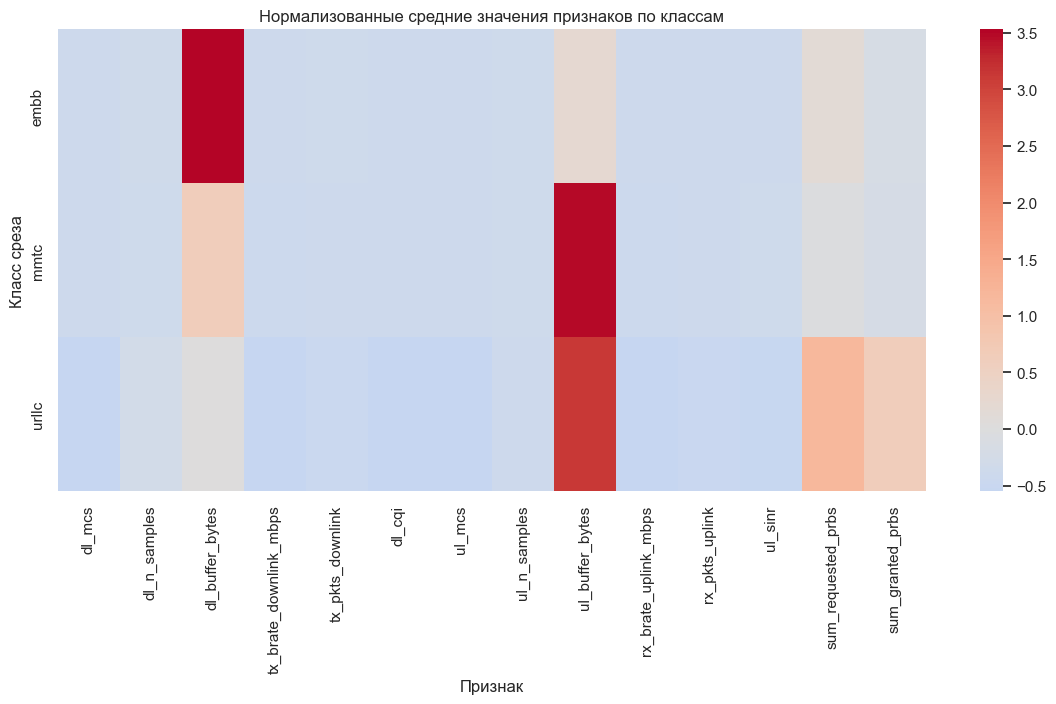

In [73]:
scaled_means = pd.DataFrame(
    StandardScaler().fit_transform(class_means.T).T,
    index=class_means.index,
    columns=class_means.columns
)

plt.figure(figsize=(14, 6))
sns.heatmap(scaled_means, cmap="coolwarm", center=0)
plt.title("Нормализованные средние значения признаков по классам")
plt.xlabel("Признак")
plt.ylabel("Класс среза")
plt.show()

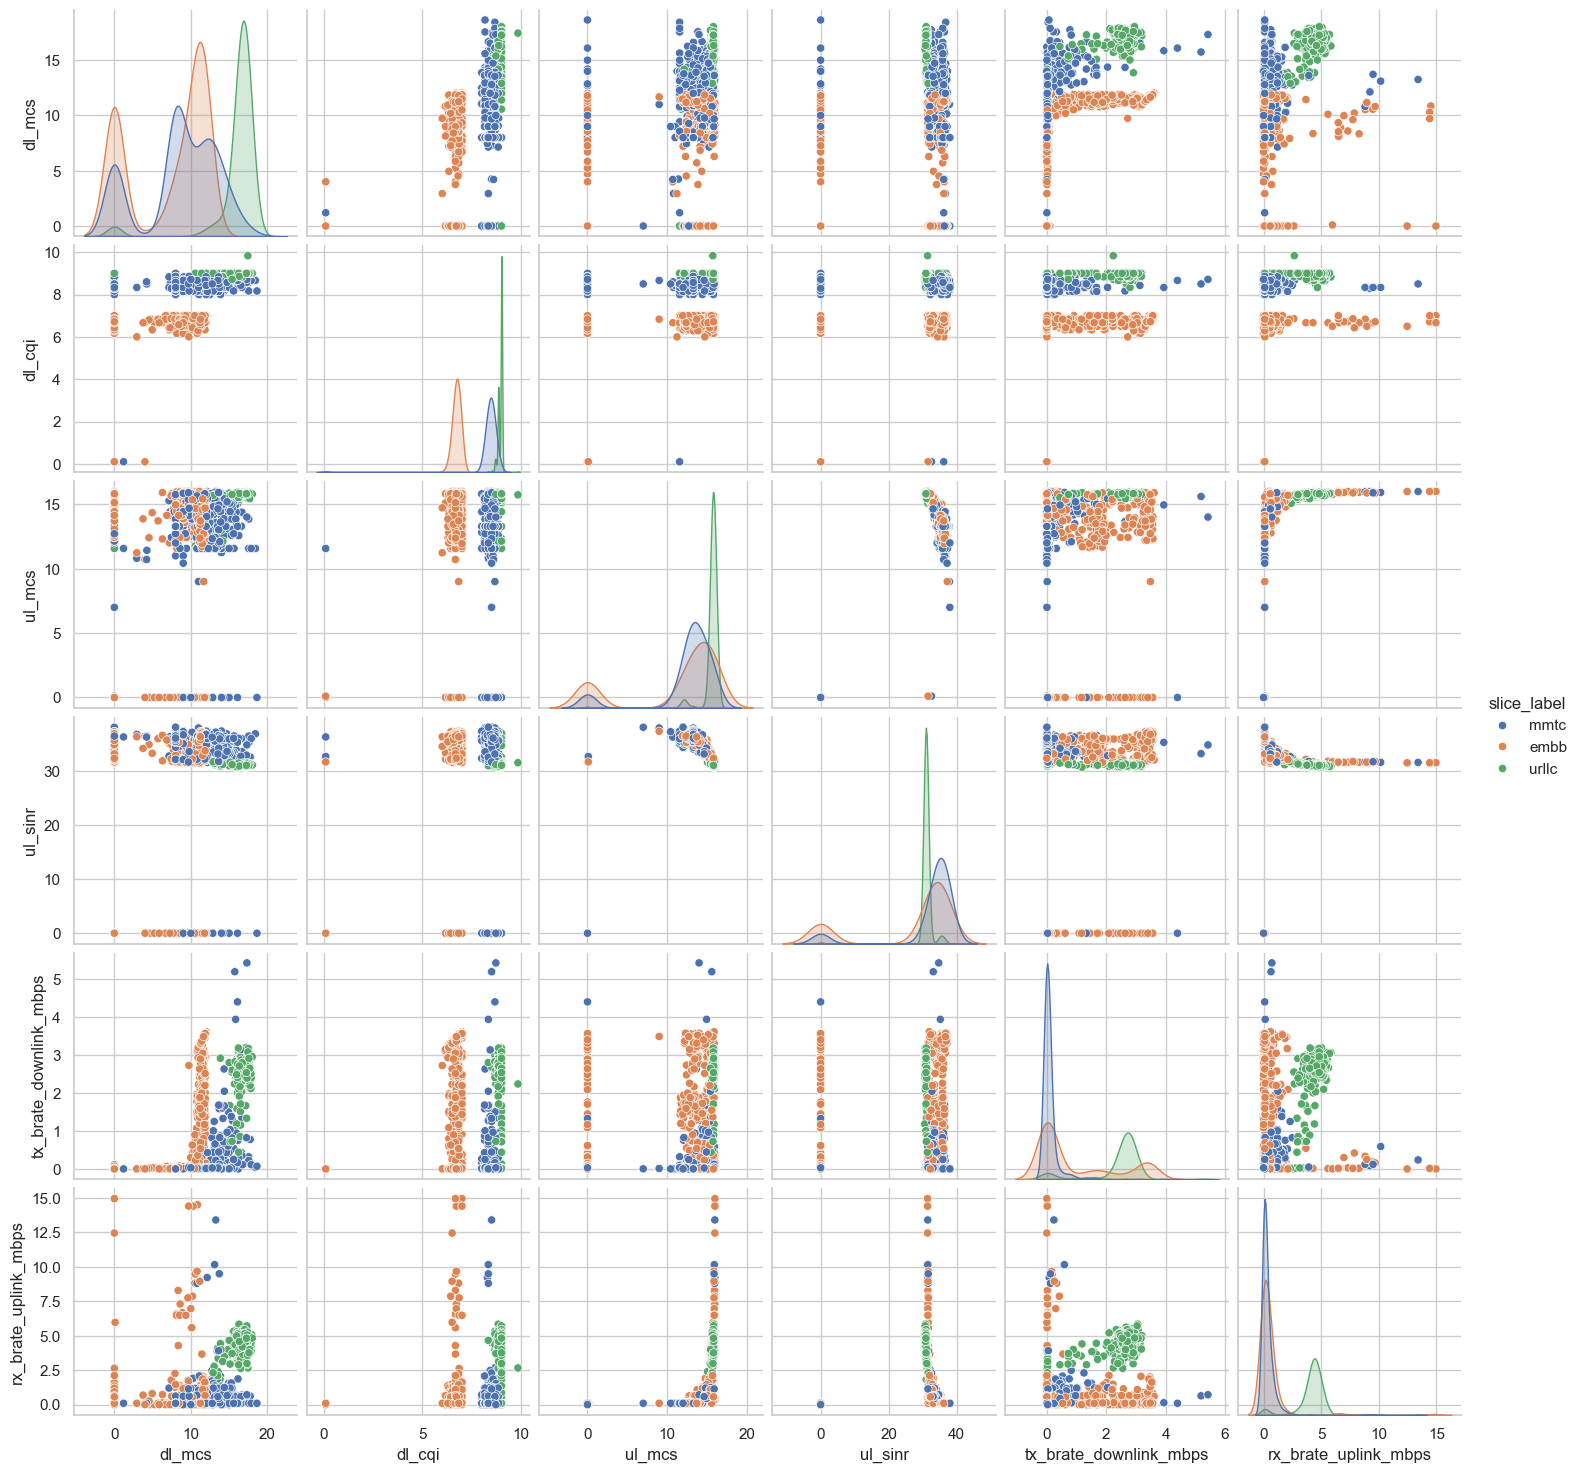

In [74]:
sample_df = df.sample(n=min(2000, len(df)), random_state=42)

pairplot_features = [
    "dl_mcs",
    "dl_cqi",
    "ul_mcs",
    "ul_sinr",
    "tx_brate_downlink_mbps",
    "rx_brate_uplink_mbps",
    target
]

pairplot_features = [col for col in pairplot_features if col in df.columns]

sns.pairplot(sample_df[pairplot_features], hue=target, diag_kind="kde")
plt.show()

In [75]:
X = df.drop(columns=[target])
y = df[target]

X = X.select_dtypes(include=["int64", "float64"])
X = X.drop(columns=constant_cols, errors="ignore")

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame({
    "pca_1": X_pca[:, 0],
    "pca_2": X_pca[:, 1],
    target: y.values
})

pca_df.head()

,pca_1,pca_2,slice_label
0,-2.068964,-0.403294,embb
1,-2.085204,-0.284751,embb
2,-1.893739,-0.232432,embb
3,-2.713661,-2.141109,embb
4,-2.701815,-2.093721,embb


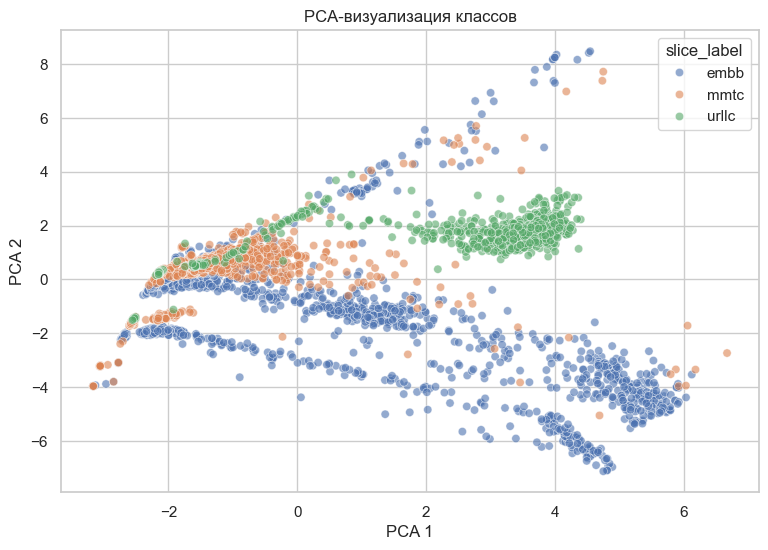

In [76]:
plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=pca_df,
    x="pca_1",
    y="pca_2",
    hue=target,
    alpha=0.6
)
plt.title("PCA-визуализация классов")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()

In [77]:
pca.explained_variance_ratio_

array([0.45740453, 0.23231115])

In [78]:
X = df.drop(columns=[target])
y = df[target]

X = X.select_dtypes(include=["int64", "float64"])
X = X.drop(columns=constant_cols, errors="ignore")

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

        embb       0.99      1.00      0.99       484
        mmtc       0.98      0.98      0.98       468
       urllc       0.98      0.98      0.98       264

    accuracy                           0.99      1216
   macro avg       0.99      0.98      0.98      1216
weighted avg       0.99      0.99      0.99      1216



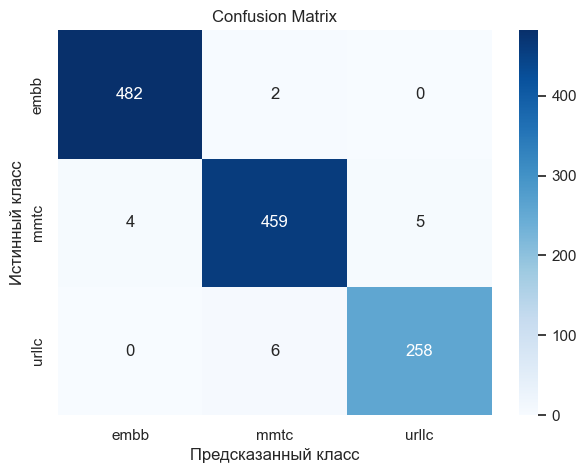

In [79]:
labels = sorted(y.unique())

cm = confusion_matrix(y_test, y_pred, labels=labels)

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels
)

plt.title("Confusion Matrix")
plt.xlabel("Предсказанный класс")
plt.ylabel("Истинный класс")
plt.show()

In [80]:
feature_importance = pd.DataFrame({
    "feature": X.columns,
    "importance": model.feature_importances_
}).sort_values("importance", ascending=False)

feature_importance

,feature,importance
5,dl_cqi,0.397475
7,ul_n_samples,0.130112
10,rx_pkts_uplink,0.099450
9,rx_brate_uplink_mbps,0.088677
0,dl_mcs,0.068333
3,tx_brate_downlink_mbps,0.042938
13,sum_granted_prbs,0.036038
11,ul_sinr,0.034415
1,dl_n_samples,0.030978
12,sum_requested_prbs,0.025115


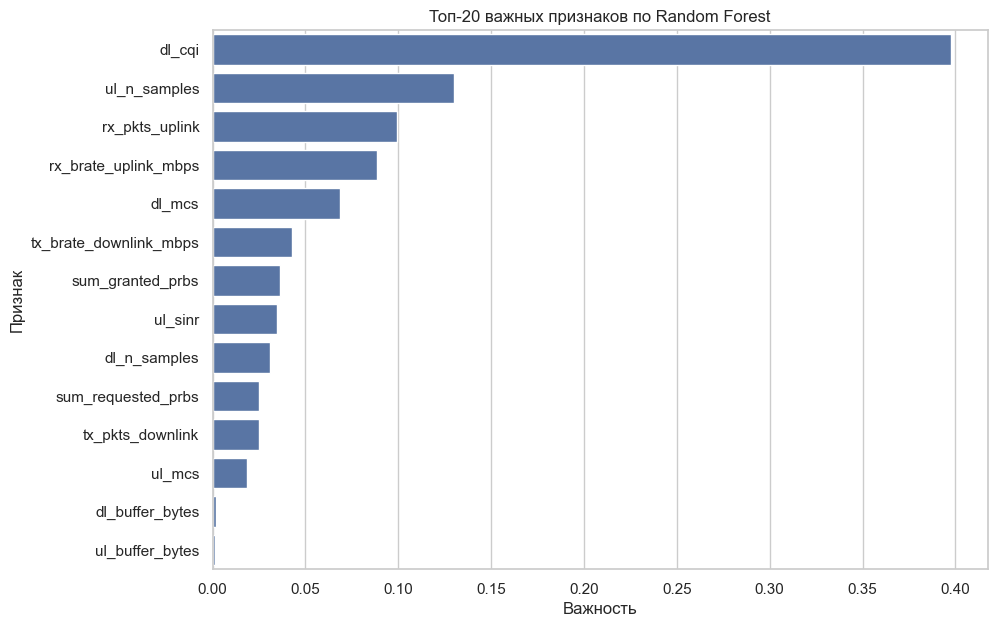

In [81]:
plt.figure(figsize=(10, 7))
sns.barplot(
    data=feature_importance.head(20),
    x="importance",
    y="feature"
)
plt.title("Топ-20 важных признаков по Random Forest")
plt.xlabel("Важность")
plt.ylabel("Признак")
plt.show()

In [82]:
target = "slice_label"

X = df.drop(columns=[target])
y = df[target]

X = X.select_dtypes(include=["int64", "float64"])

constant_cols = [
    col for col in X.columns
    if X[col].nunique(dropna=False) <= 1
]

X = X.drop(columns=constant_cols, errors="ignore")

print("Размер X:", X.shape)
print("Размер y:", y.shape)
print("Удалены константные признаки:", constant_cols)

Размер X: (6078, 14)
Размер y: (6078,)
Удалены константные признаки: []


In [83]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (4862, 14)
Test: (1216, 14)


In [84]:
from time import time

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    GradientBoostingClassifier,
    AdaBoostClassifier,
    HistGradientBoostingClassifier
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

models = {
    "Logistic Regression": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            max_iter=3000,
            class_weight="balanced",
            random_state=42
        ))
    ]),

    "KNN": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", KNeighborsClassifier(n_neighbors=5))
    ]),

    "Gaussian NB": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", GaussianNB())
    ]),

    "Linear SVM": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", LinearSVC(
            class_weight="balanced",
            max_iter=10000,
            random_state=42
        ))
    ]),

    "Decision Tree": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", DecisionTreeClassifier(
            class_weight="balanced",
            random_state=42
        ))
    ]),

    "Random Forest": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", RandomForestClassifier(
            n_estimators=200,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1
        ))
    ]),

    "Extra Trees": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", ExtraTreesClassifier(
            n_estimators=200,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1
        ))
    ]),

    "Gradient Boosting": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", GradientBoostingClassifier(
            random_state=42
        ))
    ]),

    "AdaBoost": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", AdaBoostClassifier(
            n_estimators=200,
            learning_rate=0.05,
            random_state=42
        ))
    ]),

    "Hist Gradient Boosting": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", HistGradientBoostingClassifier(
            random_state=42
        ))
    ])
}

In [85]:
results = []
trained_models = {}
predictions = {}

for name, current_model in models.items():
    start = time()

    current_model.fit(X_train, y_train)
    y_pred_current = current_model.predict(X_test)

    fit_time = time() - start

    trained_models[name] = current_model
    predictions[name] = y_pred_current

    results.append({
        "model": name,
        "accuracy": accuracy_score(y_test, y_pred_current),
        "precision_macro": precision_score(y_test, y_pred_current, average="macro", zero_division=0),
        "recall_macro": recall_score(y_test, y_pred_current, average="macro", zero_division=0),
        "f1_macro": f1_score(y_test, y_pred_current, average="macro", zero_division=0),
        "f1_weighted": f1_score(y_test, y_pred_current, average="weighted", zero_division=0),
        "fit_time_sec": fit_time
    })

results_df = pd.DataFrame(results)
results_df = results_df.sort_values("f1_macro", ascending=False)

display(results_df)

,model,accuracy,precision_macro,recall_macro,f1_macro,f1_weighted,fit_time_sec
7,Gradient Boosting,0.986842,0.985427,0.986450,0.985926,0.986834,1.878202
5,Random Forest,0.986020,0.985209,0.984637,0.984920,0.986009,0.167043
4,Decision Tree,0.985197,0.982487,0.985002,0.983688,0.985190,0.015397
9,Hist Gradient Boosting,0.985197,0.983411,0.983924,0.983664,0.985194,1.667588
1,KNN,0.982730,0.980699,0.980687,0.980692,0.982723,0.037747
6,Extra Trees,0.982730,0.982892,0.978462,0.980588,0.982681,0.237056
0,Logistic Regression,0.980263,0.977185,0.979627,0.978331,0.980237,0.027355
8,AdaBoost,0.976974,0.980029,0.968499,0.973686,0.976802,0.811568
3,Linear SVM,0.973684,0.975216,0.967899,0.971324,0.973583,0.018377
2,Gaussian NB,0.712993,0.835330,0.747236,0.727057,0.688262,0.006456


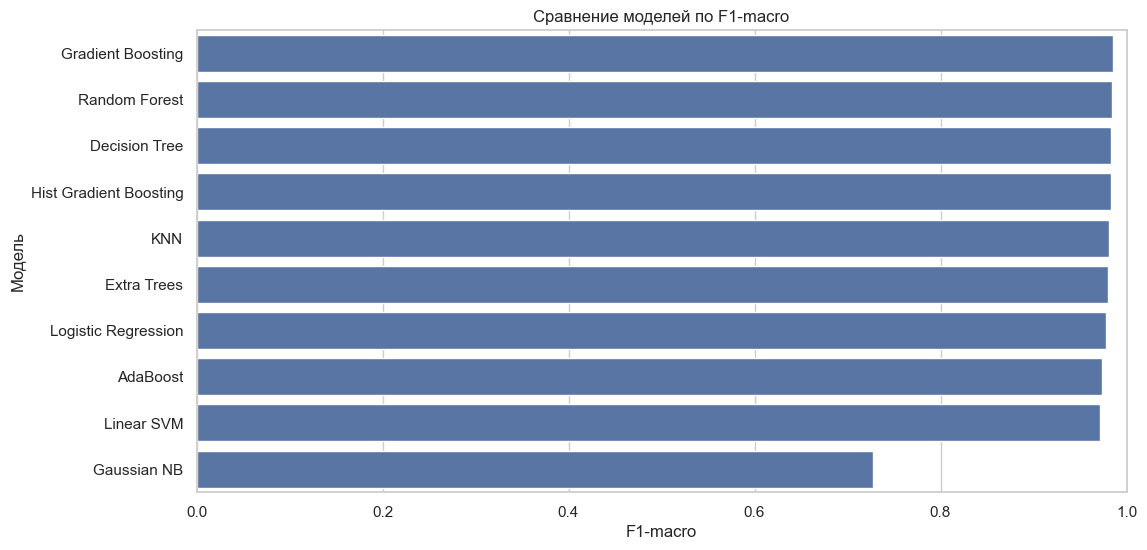

In [86]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=results_df,
    x="f1_macro",
    y="model"
)

plt.title("Сравнение моделей по F1-macro")
plt.xlabel("F1-macro")
plt.ylabel("Модель")
plt.xlim(0, 1)
plt.show()

In [87]:
from sklearn.metrics import classification_report

best_model_name = results_df.iloc[0]["model"]
best_model = trained_models[best_model_name]
best_pred = predictions[best_model_name]

print("Лучшая модель:", best_model_name)
print()
print(classification_report(y_test, best_pred))

Лучшая модель: Gradient Boosting

              precision    recall  f1-score   support

        embb       0.99      1.00      0.99       484
        mmtc       0.99      0.98      0.98       468
       urllc       0.98      0.98      0.98       264

    accuracy                           0.99      1216
   macro avg       0.99      0.99      0.99      1216
weighted avg       0.99      0.99      0.99      1216



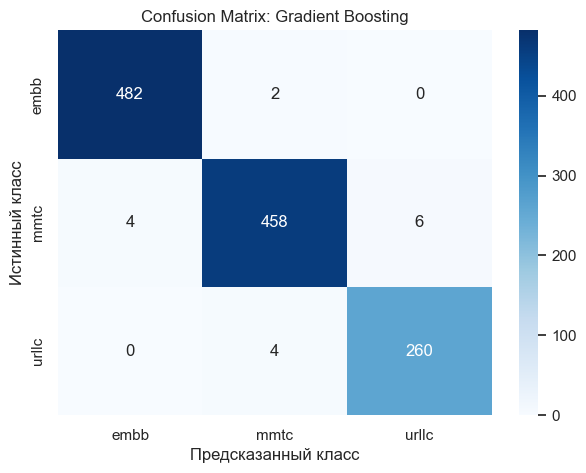

In [88]:
from sklearn.metrics import confusion_matrix

labels = sorted(y.unique())

cm = confusion_matrix(y_test, best_pred, labels=labels)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels
)

plt.title(f"Confusion Matrix: {best_model_name}")
plt.xlabel("Предсказанный класс")
plt.ylabel("Истинный класс")
plt.show()

In [89]:
from sklearn.model_selection import StratifiedKFold, cross_validate

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_results = []

for name, current_model in models.items():
    scores = cross_validate(
        current_model,
        X,
        y,
        cv=cv,
        scoring=["accuracy", "f1_macro", "f1_weighted"],
        n_jobs=-1
    )

    cv_results.append({
        "model": name,
        "accuracy_mean": scores["test_accuracy"].mean(),
        "accuracy_std": scores["test_accuracy"].std(),
        "f1_macro_mean": scores["test_f1_macro"].mean(),
        "f1_macro_std": scores["test_f1_macro"].std(),
        "f1_weighted_mean": scores["test_f1_weighted"].mean(),
        "f1_weighted_std": scores["test_f1_weighted"].std(),
        "fit_time_mean": scores["fit_time"].mean()
    })

cv_results_df = pd.DataFrame(cv_results)
cv_results_df = cv_results_df.sort_values("f1_macro_mean", ascending=False)

display(cv_results_df)

,model,accuracy_mean,accuracy_std,f1_macro_mean,f1_macro_std,f1_weighted_mean,f1_weighted_std,fit_time_mean
7,Gradient Boosting,0.989305,0.002706,0.988537,0.003066,0.989304,0.002705,1.910245
5,Random Forest,0.988647,0.003310,0.987626,0.003829,0.988646,0.003307,0.223398
4,Decision Tree,0.988154,0.002879,0.986934,0.003321,0.988154,0.002875,0.018226
9,Hist Gradient Boosting,0.987331,0.003630,0.986218,0.004132,0.987323,0.003635,0.281513
6,Extra Trees,0.986673,0.003139,0.985224,0.003501,0.986659,0.003144,0.154099
0,Logistic Regression,0.984534,0.003185,0.982590,0.003626,0.984514,0.003194,0.023903
1,KNN,0.983382,0.002408,0.982252,0.002296,0.983363,0.002403,0.012772
8,AdaBoost,0.978611,0.003490,0.975041,0.004039,0.978438,0.003535,0.779179
3,Linear SVM,0.974498,0.004796,0.972041,0.005021,0.974430,0.004790,0.020936
2,Gaussian NB,0.721621,0.008423,0.738088,0.009024,0.700701,0.011446,0.009394


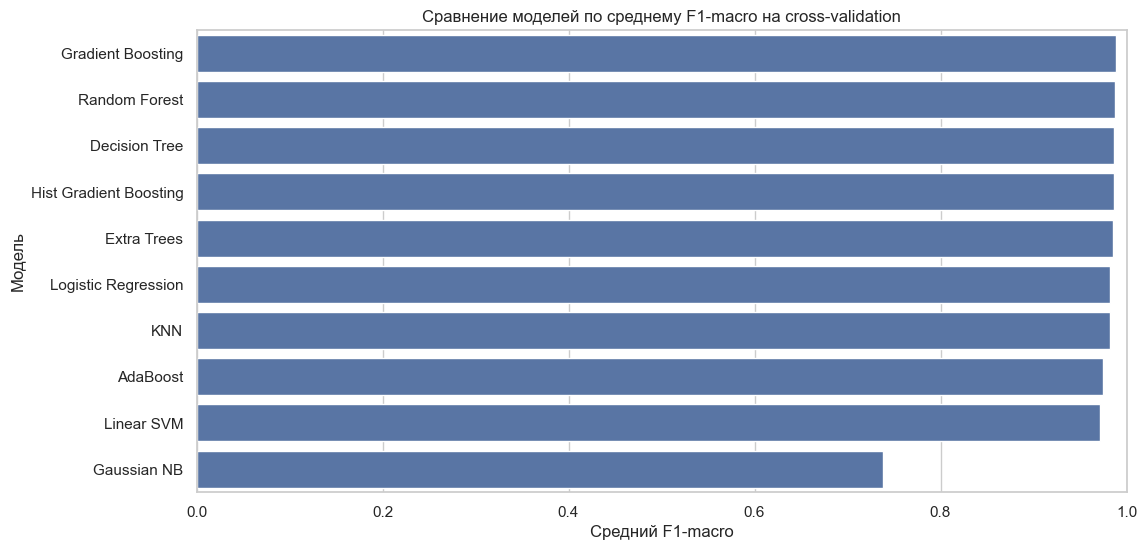

In [90]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=cv_results_df,
    x="f1_macro_mean",
    y="model"
)

plt.title("Сравнение моделей по среднему F1-macro на cross-validation")
plt.xlabel("Средний F1-macro")
plt.ylabel("Модель")
plt.xlim(0, 1)
plt.show()

In [91]:
from sklearn.inspection import permutation_importance

perm_result = permutation_importance(
    best_model,
    X_test,
    y_test,
    scoring="f1_macro",
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

perm_importance = pd.DataFrame({
    "feature": X.columns,
    "importance_mean": perm_result.importances_mean,
    "importance_std": perm_result.importances_std
}).sort_values("importance_mean", ascending=False)

display(perm_importance.head(20))

,feature,importance_mean,importance_std
5,dl_cqi,0.494339,0.016421
7,ul_n_samples,0.017370,0.003453
9,rx_brate_uplink_mbps,0.000882,0.000294
10,rx_pkts_uplink,0.000882,0.000294
4,tx_pkts_downlink,0.000701,0.000603
8,ul_buffer_bytes,0.000196,0.000392
1,dl_n_samples,0.000165,0.000987
3,tx_brate_downlink_mbps,0.000155,0.000931
13,sum_granted_prbs,0.000103,0.000691
0,dl_mcs,-0.000472,0.001131


In [94]:
from pathlib import Path
import pandas as pd
import requests

base_url = "https://raw.githubusercontent.com/genesys-neu/TRACTOR/main/logs/SingleUE/Trial2"

files = {
    "embb_clean.csv": "embb",
    "mmtc_clean.csv": "mmtc",
    "urll_clean.csv": "urllc"
}

data_dir = Path("tractor_trial2")
data_dir.mkdir(exist_ok=True)

dfs = []

for filename, label in files.items():
    url = f"{base_url}/{filename}"
    local_path = data_dir / filename

    response = requests.get(url)
    response.raise_for_status()

    local_path.write_bytes(response.content)

    df = pd.read_csv(local_path)
    df["slice_label"] = label
    dfs.append(df)

trial2_df = pd.concat(dfs, ignore_index=True)

output_path = data_dir / "singleue_trial2_combined.csv"
trial2_df.to_csv(output_path, index=False)

print(trial2_df.shape)
print(trial2_df["slice_label"].value_counts())
print(f"Saved to: {output_path}")

(9823, 20)
slice_label
embb     5848
mmtc     3810
urllc     165
Name: count, dtype: int64
Saved to: tractor_trial2\singleue_trial2_combined.csv


In [95]:
target = "slice_label"

if "X_train" in globals():
    feature_columns = list(X_train.columns)
else:
    feature_columns = list(X.columns)

X_trial2_raw = trial2_df.drop(columns=[target])
y_trial2 = trial2_df[target]

X_trial2_raw = X_trial2_raw.select_dtypes(include=["int64", "float64"])

missing_cols = sorted(set(feature_columns) - set(X_trial2_raw.columns))
extra_cols = sorted(set(X_trial2_raw.columns) - set(feature_columns))

X_trial2 = X_trial2_raw.reindex(columns=feature_columns)

print("Trial2 X:", X_trial2.shape)
print("Trial2 y:", y_trial2.shape)

print("Признаки, которых нет в Trial2:", missing_cols)
print("Лишние признаки в Trial2:", extra_cols)

Trial2 X: (9823, 14)
Trial2 y: (9823,)
Признаки, которых нет в Trial2: ['dl_buffer_bytes', 'rx_brate_uplink_mbps', 'rx_pkts_uplink', 'tx_brate_downlink_mbps', 'tx_pkts_downlink', 'ul_buffer_bytes']
Лишние признаки в Trial2: ['Timestamp', 'dl_buffer [bytes]', 'phr', 'rx_brate uplink [Mbps]', 'rx_errors uplink (%)', 'rx_pkts uplink', 'tx_brate downlink [Mbps]', 'tx_errors downlink (%)', 'tx_pkts downlink', 'ul_buffer [bytes]', 'ul_turbo_iters']


In [96]:
best_model
best_model_name

'Gradient Boosting'

In [97]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

y_trial2_pred = best_model.predict(X_trial2)

trial2_metrics = {
    "model": best_model_name,
    "accuracy": accuracy_score(y_trial2, y_trial2_pred),
    "precision_macro": precision_score(y_trial2, y_trial2_pred, average="macro", zero_division=0),
    "recall_macro": recall_score(y_trial2, y_trial2_pred, average="macro", zero_division=0),
    "f1_macro": f1_score(y_trial2, y_trial2_pred, average="macro", zero_division=0),
    "f1_weighted": f1_score(y_trial2, y_trial2_pred, average="weighted", zero_division=0)
}

trial2_metrics_df = pd.DataFrame([trial2_metrics])
display(trial2_metrics_df)

,model,accuracy,precision_macro,recall_macro,f1_macro,f1_weighted
0,Gradient Boosting,0.368217,0.133735,0.316295,0.180547,0.210426


In [98]:
print(classification_report(y_trial2, y_trial2_pred))

              precision    recall  f1-score   support

        embb       0.02      0.00      0.00      5848
        mmtc       0.38      0.95      0.54      3810
       urllc       0.00      0.00      0.00       165

    accuracy                           0.37      9823
   macro avg       0.13      0.32      0.18      9823
weighted avg       0.16      0.37      0.21      9823



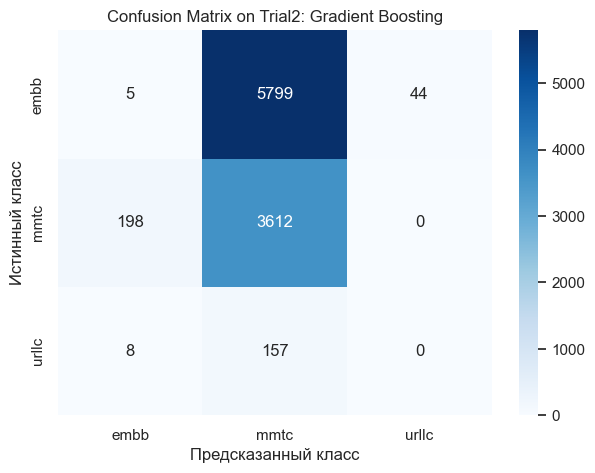

In [99]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

labels = sorted(y_trial2.unique())

cm = confusion_matrix(y_trial2, y_trial2_pred, labels=labels)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels
)

plt.title(f"Confusion Matrix on Trial2: {best_model_name}")
plt.xlabel("Предсказанный класс")
plt.ylabel("Истинный класс")
plt.show()

In [100]:
trial2_results = []

for name, current_model in trained_models.items():
    y_pred_current = current_model.predict(X_trial2)

    trial2_results.append({
        "model": name,
        "accuracy": accuracy_score(y_trial2, y_pred_current),
        "precision_macro": precision_score(y_trial2, y_pred_current, average="macro", zero_division=0),
        "recall_macro": recall_score(y_trial2, y_pred_current, average="macro", zero_division=0),
        "f1_macro": f1_score(y_trial2, y_pred_current, average="macro", zero_division=0),
        "f1_weighted": f1_score(y_trial2, y_pred_current, average="weighted", zero_division=0)
    })

trial2_results_df = pd.DataFrame(trial2_results)
trial2_results_df = trial2_results_df.sort_values("f1_macro", ascending=False)

display(trial2_results_df)

,model,accuracy,precision_macro,recall_macro,f1_macro,f1_weighted
2,Gaussian NB,0.529879,0.467421,0.410713,0.338375,0.476002
3,Linear SVM,0.504327,0.388845,0.380704,0.331155,0.472812
1,KNN,0.503309,0.423493,0.389983,0.321595,0.451237
0,Logistic Regression,0.436628,0.325174,0.330878,0.285997,0.405394
4,Decision Tree,0.367607,0.152721,0.317703,0.183513,0.209799
6,Extra Trees,0.370762,0.141434,0.318361,0.181175,0.211433
7,Gradient Boosting,0.368217,0.133735,0.316295,0.180547,0.210426
9,Hist Gradient Boosting,0.367301,0.133203,0.315508,0.180205,0.210028
5,Random Forest,0.367098,0.135329,0.315272,0.179730,0.209611
8,AdaBoost,0.366996,0.135262,0.315185,0.179693,0.209568


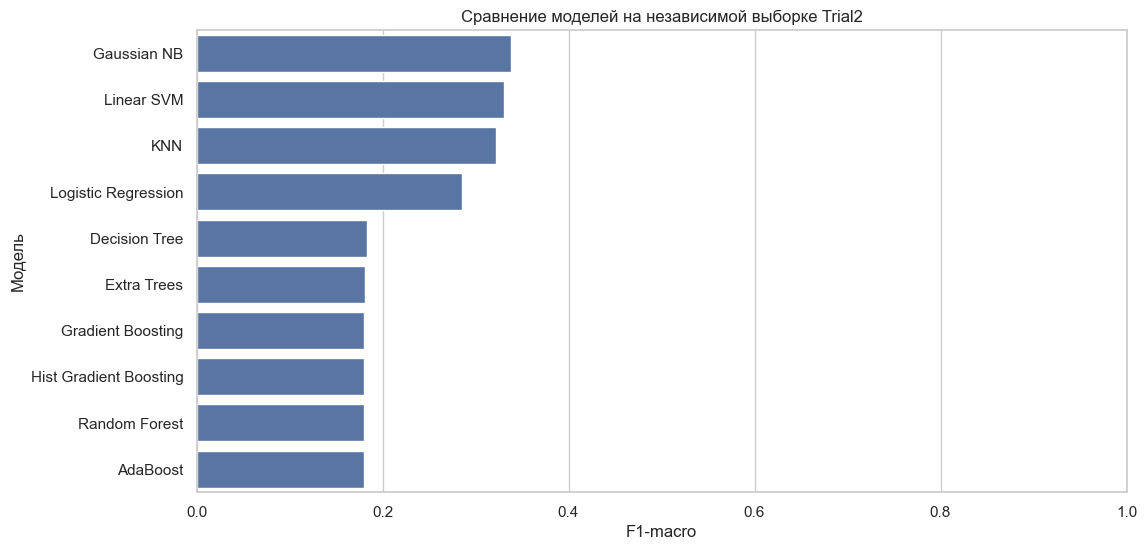

In [101]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=trial2_results_df,
    x="f1_macro",
    y="model"
)

plt.title("Сравнение моделей на независимой выборке Trial2")
plt.xlabel("F1-macro")
plt.ylabel("Модель")
plt.xlim(0, 1)
plt.show()

In [102]:
trial1_test_results = results_df.copy()
trial1_test_results["dataset"] = "Trial1 test"

trial2_compare_results = trial2_results_df.copy()
trial2_compare_results["dataset"] = "Trial2 external test"

compare_df = pd.concat(
    [trial1_test_results, trial2_compare_results],
    ignore_index=True
)

display(compare_df.sort_values(["model", "dataset"]))

,model,accuracy,precision_macro,recall_macro,f1_macro,f1_weighted,fit_time_sec,dataset
7,AdaBoost,0.976974,0.980029,0.968499,0.973686,0.976802,0.811568,Trial1 test
19,AdaBoost,0.366996,0.135262,0.315185,0.179693,0.209568,NaN,Trial2 external test
2,Decision Tree,0.985197,0.982487,0.985002,0.983688,0.985190,0.015397,Trial1 test
14,Decision Tree,0.367607,0.152721,0.317703,0.183513,0.209799,NaN,Trial2 external test
5,Extra Trees,0.982730,0.982892,0.978462,0.980588,0.982681,0.237056,Trial1 test
15,Extra Trees,0.370762,0.141434,0.318361,0.181175,0.211433,NaN,Trial2 external test
9,Gaussian NB,0.712993,0.835330,0.747236,0.727057,0.688262,0.006456,Trial1 test
10,Gaussian NB,0.529879,0.467421,0.410713,0.338375,0.476002,NaN,Trial2 external test
0,Gradient Boosting,0.986842,0.985427,0.986450,0.985926,0.986834,1.878202,Trial1 test
16,Gradient Boosting,0.368217,0.133735,0.316295,0.180547,0.210426,NaN,Trial2 external test


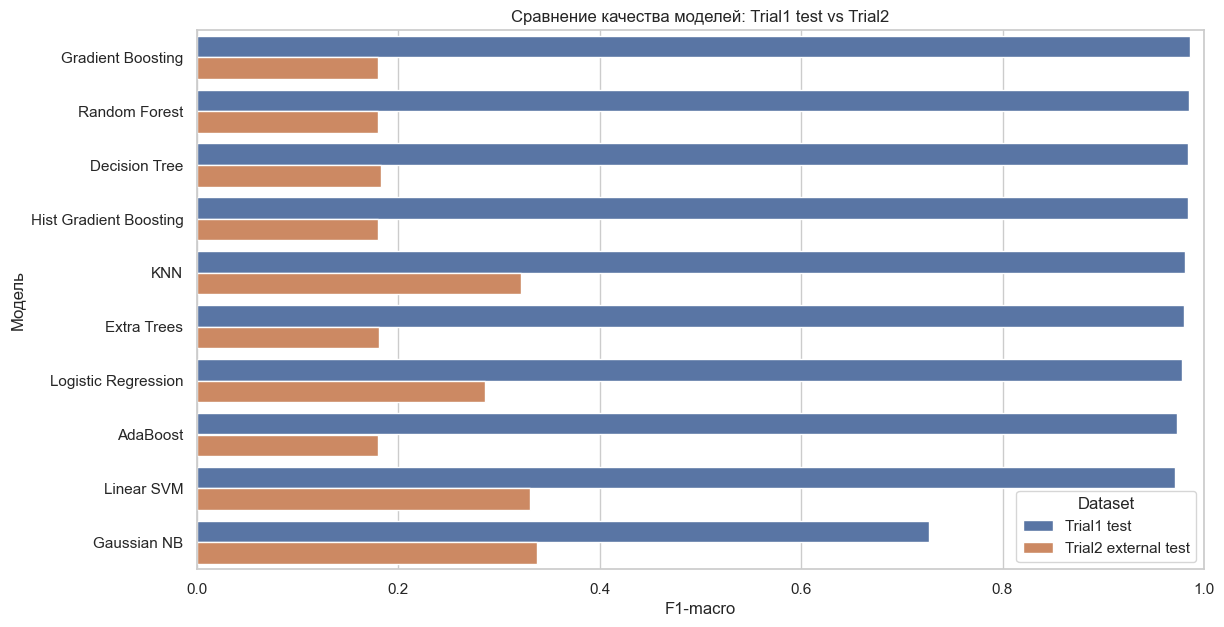

In [103]:
plt.figure(figsize=(13, 7))

sns.barplot(
    data=compare_df,
    x="f1_macro",
    y="model",
    hue="dataset"
)

plt.title("Сравнение качества моделей: Trial1 test vs Trial2")
plt.xlabel("F1-macro")
plt.ylabel("Модель")
plt.xlim(0, 1)
plt.legend(title="Dataset")
plt.show()